# NB09 Guardian API Methodology (unstructured signal)

**API** the Guardian Open Platform API

**What** this notebook is for is

The notebook will link *structured* Companies House data with *unstructured* news data. We can't pull news for all 1.37M companies (the APIs simply won't allow that many calls), so instead we build **one reliable tool**: you give it a company, and it returns that company's news articles, a coverage count, and a sentiment score.

So This notebook **builds and tests that tool using the Guardian API**, on Viktor's ready-made 96-company sample. Once it works here, the exact same tool probably can be pointed at a targeted ~100-company sample (selected on structured signals like debt ratio) to produce a real result.

> Note nothing is final here until we have decided to move forward

Flow diagram to have a clear understanding

1.37M companies (structured Companies House data)
        │   filter on structured metrics (debt ratio, age, segment, etc.)
        ▼
   small set of companies  (~96 for testing (viktori) / ~100 for the real run)
        │
        ▼   ◄────────  THIS NOTEBOOK (Guardian source)
   for each company: we find news → score it → one tidy row
        │
        ▼   Then join back on CompanyNumber
   structured + unstructured  =  the combined, more powerful result
This notebook does the middle box, for the Guardian. For every company it runs the same small procedure:

search_name + town + sector
        │  build a precise Guardian query
        ▼
   call /search  ──►  response.total = how many articles exist (coverage count)
        │
        ▼  keep only articles that are genuinely about THIS company
   verify each hit (name in the body + a matching town / sector word)
        │
        ▼  run sentiment on the text we trust
   sentiment score + label
        │
        ▼
   one row:  CompanyNumber · articles · coverage_count · sentiment · …


_**Tool output**_ (experimental)

| Column | Meaning | Locaton |
|---|---|---|
| `CompanyNumber` | The unique company id that is our join key everywhere | Companies House |
| `CompanyNamw` | Human-readable name (for sanity checks only, never for joining) | Companies House |
| `news_coverage_count` | How many Guardian articles match (0 is a valid answer!) | `response.total` |
| `n_verified` | How many of those we confirmed are really about this company | our verification step |
| `articles` | The kept articles (title, url, date) | `response.results` |
| `sentiment_score` | Tone of the coverage, roughly −1 (negative) to +1 (positive) | sentiment model |
| `sentiment_label` | positive / neutral / negative | derived from the score |
| `search_date` | The date we collected the data (so results are reproducible) | pinned constant |

**2 things which i believe are important to keep the outcome trustworthy**

1. **Disambiguation is built in.** Lots of companies share names with unrelated things, and the Guardian search can return loosely-matching articles. So to *verify* every outcome against the company's town / sector before trusting it.
2. **`CompanyNumber`** Company *names* tend to clash and change; the number never does. so join on the number, never the name.


## 1. Config & constants

So Before any API calls, I set everything up in one place.

- **SEARCH_DATE** is pinned to a fixed day. The methodology chapter can then cite an exact data-collection date.
- **3 year** date window. UK SMEs dont appear much in the news, so a short window (weeks/months) would return almost nothing. A 3-year window maybe a good idea to get *any* signal (As guardian is quite vauge). We still keep each article's publication date, so we can look at recency later if we want.
- **Sections** I have hard-filtered to `business - money - technology - uk_new`. (This trades a little recall for a lot of precision)
- **Rate limits:** the free Guardian tier allows **1 call/second** and **500 calls/day**, with full article text.

In [1]:
# Imports
import os
import time
import json
import requests
import pandas as pd
from pathlib import Path
from datetime import datetime

#Reproducibility: pin the data-collection date
SEARCH_DATE  = "2026-06-30"          # the day we treat as "now" for this run
WINDOW_YEARS = 3                      # how far back we look for articles

_sd = datetime.strptime(SEARCH_DATE, "%Y-%m-%d")
FROM_DATE = _sd.replace(year=_sd.year - WINDOW_YEARS).strftime("%Y-%m-%d")
TO_DATE   = SEARCH_DATE
print(f"Collecting Guardian articles from {FROM_DATE} to {TO_DATE} (a {WINDOW_YEARS}-year window)")

#Guardian endpoint & query settings
GUARDIAN_URL = "https://content.guardianapis.com/search"
SECTIONS     = "business|money|technology|uk-news"   # hard section filter ( | means OR )
SHOW_FIELDS  = "headline,trailText,standfirst,body,wordcount,byline"
SHOW_TAGS    = "keyword,tone,type"
PAGE_SIZE    = 50                    # max allowed; one page is plenty per company

#Rate limiting (free developer tier)
RATE_LIMIT_SECONDS = 1.0             # 1 call/second
DAILY_CALL_BUDGET  = 500             # 500 calls/day

#The API key is read from an environment variable, and not hardcoded.
#The earlier notebooks i pasted real keys straight into the cells, 
#which means those keys are now exposed in the git history. Set your key once in your environment (or a local `.env`) and the notebook reads it.
GUARDIAN_API_KEY = os.environ.get("GUARDIAN_API_KEY", "")
if GUARDIAN_API_KEY:
    print("Guardian API key loaded from environment.")
else:
    print("No GUARDIAN_API_KEY found. Set it before running the API cells, e.g.:")
    print('   Windows (PowerShell):  $env:GUARDIAN_API_KEY = "your-key-here"')
    print('   Or put it in a local .env file (and keep .env out of git).')

No GUARDIAN_API_KEY found. Set it before running the API cells, e.g.:
   Windows (PowerShell):  $env:GUARDIAN_API_KEY = "your-key-here"
   Or put it in a local .env file (and keep .env out of git).


---
**Load the 96-company sample**

I previously build and tested on Viktor's existing sample of 96 companies, in NB08 but as I wasnt using a properly tuned query and the suggested way of use from guardian it was mostly giving false positives 

Will again try first on the same sampe for three reasons:

1. It already has a `search_name` column (the company name cleaned up for searching) and `query_templates`.
2. Its Balanced too with 24 companies each of Large - Medium - Micro - Small, evenly across the 3 sectors. 

The data lives one level up from the repo (in the outer `data/processed` folder), so I search a couple of likely locations instead of hardcoding one path. I also strip the column names, because some Companies House columns have annoying leading spaces.

In [2]:
# Find the sample (it lives in the outer data/processed folder, not inside the repo)
NB_DIR = Path.cwd()                 # .../notebooks
REPO   = NB_DIR.parent             # repo root

candidates = [
    REPO / "data" / "processed" / "nb04_stress_test_sample.csv",          # inside repo (if it ever moves here)
    REPO.parent / "data" / "processed" / "nb04_stress_test_sample.csv",   # outer Lloyds_Github/data (current home)
]

SAMPLE_PATH = next((p for p in candidates if p.exists()), None)
if SAMPLE_PATH is None:
    raise FileNotFoundError(
        "Could not find nb04_stress_test_sample.csv. Looked in:\n  "
        + "\n  ".join(str(p) for p in candidates)
    )

sample = pd.read_csv(SAMPLE_PATH)
sample.columns = sample.columns.str.strip()   # fix leading spaces in column names
print(f"Loaded {len(sample)} companies from: {SAMPLE_PATH}")

Loaded 96 companies from: C:\Users\visha\Lloyds_Github\data\processed\nb04_stress_test_sample.csv


In [3]:
# Quick look at the sample so we know exactly what we're working with
print("Rows:", len(sample))
print("\nBalance check (segment x sector):")
print(pd.crosstab(sample["segment"], sample["sector"], margins=True))

print("\nThe columns we'll lean on:")
preview_cols = ["CompanyName", "CompanyNumber", "RegAddress.PostTown", "sector", "segment", "search_name"]
preview_cols = [c for c in preview_cols if c in sample.columns]
print(sample[preview_cols].head(8).to_string(index=False))

Rows: 96

Balance check (segment x sector):
sector   Fast growth & emerging  Manufacturing  \
segment                                          
Large                         8              8   
Medium                        8              8   
Micro                         8              8   
Small                         8              8   
All                          32             32   

sector   Technology, legal & professional  All  
segment                                         
Large                                   8   24  
Medium                                  8   24  
Micro                                   8   24  
Small                                   8   24  
All                                    32   96  

The columns we'll lean on:
                                        CompanyName CompanyNumber RegAddress.PostTown                 sector segment                                                                   search_name
                                       

**What to expect:** 96 rows, a clean 8-per-cell grid (24 per size tier, 32 per sector), and a `search_name` that already has the `LTD`/`LIMITED` bits stripped off. If anything looks off here, we fix it before going near the API.

## 3. Search query

here i will turn a company into a Guardian query that finds **the right** articles.

On a side note* in the 96 sample data `search_name` column isn't just the company name, it's the name, town, and sector all stuck into one string, e.g. `whalar london fast growth & emerging`. That isfine for some uses, but it's a poor thing to search on:
- Quoting the whole string as an exact phrase matches *nothing* (no article says that exact sentence).
- Taking the first few words (check NB08) mangles longer names like e.g. *CME Technology and Support Services* becomes **cme technology and**.

So instead, I've cleaned the company name here from `CompanyName` (strip the `LTD`/`LIMITED`/etc. bits) and use that as an exact phrase. 
- The town and sector are kept **separately**
- we'll use them in the verification step to check a hit is genuine, rather than forcing into the search.

Q) **Why keep town/sector out of the search itself?** 
- If I demanded the article also contain the town, I wuold throw away real articles that just don't happen to mention it (a story about a company often won't name its town).
- And for London companies the town is a bit of weak filter as "London" appears in half the paper.
- Better to search precisely on the name, then verify afterwards. 

The query itself uses:
- `q = "<clean name>"` : exact phrase, so *Acme Joinery* doesn't match *acme* + *joinery* scattered about.
- `query-fields=body` : the name must appear in the **article body**, and not just a loose field match.

> **Heads-up on special characters.** Some company names contain `&`, `(`, `)` or `|`, which the Guardian `q` parameter reads as *operators* - so a name like `J.A. Harrison & Company (Manchester)` returns a `400 Bad Request`. The `to_query_phrase()` function below makes the name safe: it drops bracketed bits, turns `&` into 'and', and keeps only letters, numbers and spaces.

In [4]:
import os, getpass
os.environ["GUARDIAN_API_KEY"] = getpass.getpass("Guardian API key:")
#getpass hides the key as you type and keeps it out of the saved notebook, so nothing leaks into git.

Guardian API key: ········


In [5]:
import re

# Legal-form endings to strip so "ACME JOINERY LIMITED" -> "Acme Joinery"
LEGAL_SUFFIXES = [
    " LIMITED", " LTD", " PLC", " LLP", " LP", " CIC",
    " INC", " CORP", " CORPORATION", " GROUP", " HOLDINGS", " COMPANY", " CO",
]

def clean_company_name(raw_name: str) -> str:
    """Strip legal suffixes and trailing punctuation to get a readable name."""
    name = str(raw_name).upper().strip().rstrip(" ,.")
    changed = True
    while changed:                      # loop handles stacked endings like ", LTD"
        changed = False
        for suffix in LEGAL_SUFFIXES:
            if name.endswith(suffix):
                name = name[:-len(suffix)].strip().rstrip(" ,.")
                changed = True
    return name.title()                 # Guardian search is case-insensitive; .title() just reads nicely

def to_query_phrase(clean_name: str) -> str:
    """Make a name SAFE for the Guardian `q` parameter.

    The q syntax treats & ( ) | and other punctuation as operators, so a raw name like
    'J.A. Harrison & Company (Manchester)' causes a 400 Bad Request. We therefore:
      - drop bracketed qualifiers like '(Manchester)',
      - turn '&' into 'and',
      - keep only letters, numbers and spaces.
    """
    name = re.sub(r"\(.*?\)", " ", clean_name)     # remove "(Manchester)" style bits
    name = name.replace("&", " and ")
    name = re.sub(r"[^A-Za-z0-9 ]+", " ", name)     # strip any remaining punctuation
    name = re.sub(r"\s+", " ", name).strip()
    return name

# Sector -> a few words we'd expect in a genuine article (used later, in verification)
SECTOR_KEYWORDS = {
    "Manufacturing":                    ["manufacturing", "factory", "production", "engineering"],
    "Technology, legal & professional": ["technology", "software", "legal", "consultancy", "services"],
    "Fast growth & emerging":           ["startup", "funding", "investment", "scale-up", "growth"],
}

def build_query(clean_name: str) -> str:
    """The Guardian q value: the cleaned, query-safe name as an exact phrase.
    Returns '' if the name is too short/garbled to search safely."""
    phrase = to_query_phrase(clean_name)
    return f'"{phrase}"' if len(phrase) >= 3 else ""

# Build the readable name and the actual search phrase
sample["clean_name"]    = sample["CompanyName"].apply(clean_company_name)
sample["search_phrase"] = sample["clean_name"].apply(to_query_phrase)

# Show some normal names, then specifically the tricky ones with & or brackets,
# so we can confirm the sanitising works on the names that caused the 400.
print("Normal names:")
print(sample[["CompanyName", "search_phrase"]].head(5).to_string(index=False))

tricky = sample[sample["CompanyName"].str.contains(r"[&()]", regex=True, na=False)]
if len(tricky):
    print("\nTricky names (had & or brackets) - now made query-safe:")
    print(tricky[["CompanyName", "search_phrase"]].head(8).to_string(index=False))

Normal names:
                                        CompanyName                                  search_phrase
                                         WHALAR LTD                                         Whalar
                                            NCB RIP                                        Ncb Rip
EXODUSPOINT CAPITAL MANAGEMENT UK TECHNOLOGIES, LTD Exoduspoint Capital Management Uk Technologies
                               AKSIA EUROPE LIMITED                                   Aksia Europe
        CME TECHNOLOGY AND SUPPORT SERVICES LIMITED            Cme Technology And Support Services

Tricky names (had & or brackets) - now made query-safe:
                                 CompanyName            search_phrase
J.A. HARRISON & COMPANY (MANCHESTER) LIMITED J A Harrison and Company
              SHAW TIMBER (HOLDINGS) LIMITED              Shaw Timber
                ADVANIA UK (SERVIUM) LIMITED               Advania Uk
       RADIO COMPUTING SERVICES (UK) LIMITED Radio Comp

---
## 4.fetch function (rate-limited + cached)

This wraps the actual API call. (Two imp things)

- **Caching.** The first time we look up a company, we save the raw JSON response to disk (`data/raw/search_cache/<CompanyNumber>_guardian.json`). Every run after that reads from the file instead of calling the API. This means: (1) we don't burn our 500/day budget re-running cells, and (2) results are reproducible.
  
- **Rate limiting.** We sleep 1 second after each *real* API call (the free tier allows 1/second). Cached lookups don't sleep, so re-runs are quick.



In [6]:
# Cache lives next to the data (.../data/raw/search_cache), wherever the data root actually is
CACHE_DIR = SAMPLE_PATH.parent.parent / "raw" / "search_cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)
print("Cache folder:", CACHE_DIR)

EMPTY_RESPONSE = {"response": {"total": 0, "results": []}}

def guardian_search(company_number: str, clean_name: str, api_key: str, use_cache: bool = True) -> tuple:
    """Look up one company on the Guardian.

    Returns (raw_response_dict, source). source is one of:
      'cache' - read from disk          'api'   - freshly fetched and cached
      'skip'  - name unsearchable        'error' - the API returned a non-200 (not cached, so a re-run retries)
    It never raises on a bad single company, so one odd name can't halt the whole 96-scan.
    """
    cache_file = CACHE_DIR / f"{company_number}_guardian.json"

    # 1) Use the cached copy if we already have one
    if use_cache and cache_file.exists():
        return json.loads(cache_file.read_text(encoding="utf-8")), "cache"

    # 2) Skip names that sanitised down to nothing searchable
    query = build_query(clean_name)
    if not query:
        return EMPTY_RESPONSE, "skip"

    # 3) Call the API
    params = {
        "q":            query,
        "query-fields": "body",          # name must appear in the article body
        "section":      SECTIONS,        # business|money|technology|uk-news
        "from-date":    FROM_DATE,
        "to-date":      TO_DATE,
        "lang":         "en",
        "order-by":     "relevance",
        "page-size":    PAGE_SIZE,
        "show-fields":  SHOW_FIELDS,
        "show-tags":    SHOW_TAGS,
        "api-key":      api_key,
    }
    resp = requests.get(GUARDIAN_URL, params=params, timeout=30)

    if resp.status_code != 200:
        print(f"   [warning] {resp.status_code} for {clean_name!r} -> skipped (not cached)")
        return EMPTY_RESPONSE, "error"   # don't cache errors

    data = resp.json()
    cache_file.write_text(json.dumps(data, ensure_ascii=False), encoding="utf-8")
    time.sleep(RATE_LIMIT_SECONDS)
    return data, "api"

def summarise_response(data: dict) -> tuple:
    """Pull the headline numbers out of a raw response: (total_matches, returned_now, first_few_titles)."""
    r = data.get("response", {})
    total   = r.get("total", 0)
    results = r.get("results", [])
    titles  = [a.get("webTitle", "") for a in results[:3]]
    return total, len(results), titles

Cache folder: C:\Users\visha\Lloyds_Github\data\raw\search_cache


## 4b. Doing a test on a few companies

I'll run it on the first 3 companies just to see it working end-to-end. This costs **3 API calls** (out of 500/day) the first time; after that it reads from the cache and is free.

something i lookout for is two things: the **coverage count** (`total`), and whether the returned titles actually look like they're about our company.

**So to explain in plain words**
- If Tesco returns lots of articles (hundreds/thousands), the API call, key, date window and filters all work - so the zeros for our small companies are **real**, not a bug.
- You should see the count get smaller as each filter is added. That's expected and healthy - `query-fields=body` in particular drops articles that only mention "Tesco" in passing metadata.
- If even Tesco returns 0, something's wrong (key, date format, or a filter typo) and we fix that before going further.

## 5. Now below check coverage all 96 companies

Now i will run the real fetch on the whole sample to answer: *how many of these 96 companies have any Guardian coverage at all, and does it depend on company size?*

This is ~96 API calls the first time (pls check with the limits when you run it twice) We're only collecting the **coverage count** here and finding articles is one job, deciding which are genuine is the next (verification).

In [7]:


counts, sources = [], []
for i, (_, row) in enumerate(sample.iterrows(), start=1):
    data, source = guardian_search(row["CompanyNumber"], row["clean_name"], GUARDIAN_API_KEY)
    total, _, _ = summarise_response(data)
    counts.append(total)
    sources.append(source)
    if i % 20 == 0:
        print(f"  ...{i}/{len(sample)} done")

sample["coverage_count"] = counts
print(f"\nDone. api={sources.count('api')}, cache={sources.count('cache')}, "
      f"skip={sources.count('skip')}, error={sources.count('error')}")
if sources.count('error'):
    print("Some companies errored (left uncached) - just re-run this cell to retry them.")

  ...20/96 done
  ...40/96 done
  ...60/96 done
  ...80/96 done

Done. api=0, cache=96, skip=0, error=0


In [8]:
# How much coverage did we actually find?
n_cov = int((sample["coverage_count"] > 0).sum())
print(f"Companies with at least 1 Guardian article: {n_cov} / {len(sample)} ({n_cov/len(sample):.1%})")
print(f"Total articles across all companies: {int(sample['coverage_count'].sum())}")

print("\nCoverage by size tier:")
tier = sample.groupby("segment").agg(
    companies     = ("CompanyNumber", "count"),
    with_coverage = ("coverage_count", lambda s: int((s > 0).sum())),
    total_articles= ("coverage_count", "sum"),
)
tier["coverage_rate"] = (tier["with_coverage"] / tier["companies"] * 100).round(1)
print(tier.to_string())

print("\nThe companies that DO have coverage (these are what verification will work on):")
covered = sample[sample["coverage_count"] > 0].sort_values("coverage_count", ascending=False)
print(covered[["clean_name", "segment", "sector", "RegAddress.PostTown", "coverage_count"]].head(20).to_string(index=False))

Companies with at least 1 Guardian article: 5 / 96 (5.2%)
Total articles across all companies: 83

Coverage by size tier:
         companies  with_coverage  total_articles  coverage_rate
segment                                                         
Large           24              2               4            8.3
Medium          24              1              62            4.2
Micro           24              1              16            4.2
Small           24              1               1            4.2

The companies that DO have coverage (these are what verification will work on):
         clean_name segment                           sector RegAddress.PostTown  coverage_count
           Baroness  Medium Technology, legal & professional                 NaN              62
            Coaster   Micro           Fast growth & emerging              LONDON              16
                Ncc   Large Technology, legal & professional          MANCHESTER               3
           Brs Golf

## 6. Verification / disambiguation



The main idea here is that an article is *verified* if the company name appears as a phrase **and** there's at least one corroborating signal:
- *T* : the company's town appears in the article,
- *S* : a sector keyword appears (from `SECTOR_KEYWORDS`),
- *C* : general business-context words appear (company, firm, CEO, turnover, ...).

**Single-word names are treated more strictly.** A name like "Baroness" or "Coaster" is one common word, so business-context alone isn't enough, so we require the **town** to be present too.

In [9]:
import re
from html import unescape

# Words that suggest an article is about a *business* (separates a company from a same-named person/thing)
BUSINESS_CONTEXT = [
    "company", "firm", "business", "ltd", "limited", "plc", "group", "holdings",
    "ceo", "chief executive", "founder", "director", "turnover", "revenue", "profit",
    "acquisition", "merger", "contract", "customers", "employees", "staff", "headquarters",
]

# Fix 3: common-word company names that can't be matched by name reliably (extend when you spot one)
UNSEARCHABLE_NAMES = {"coaster", "baroness"}

def _article_text(article: dict) -> str:
    """Whole article (title + all fields), lowercase, tag-free - used for corroboration signals."""
    f = article.get("fields", {})
    blob = " ".join([article.get("webTitle", ""), f.get("headline", ""), f.get("standfirst", ""),
                     f.get("trailText", ""), f.get("body", "")])
    return unescape(re.sub(r"<[^>]+>", " ", blob)).lower()

def _summary_text(article: dict) -> str:
    """Only the summary fields (title/headline/standfirst/trail) - where an article names what it is ABOUT."""
    f = article.get("fields", {})
    blob = " ".join([article.get("webTitle", ""), f.get("headline", ""),
                     f.get("standfirst", ""), f.get("trailText", "")])
    return unescape(re.sub(r"<[^>]+>", " ", blob)).lower()

def _mentions(text: str, phrase: str) -> bool:
    """Fix 1: True only if phrase stands alone - not inside another word or hyphenated.
    So 'coaster' no longer matches 'roller-coaster', which was the main false-positive source."""
    return re.search(r"(?<![\w-])" + re.escape(phrase) + r"(?![\w-])", text) is not None

def verify_article(article: dict, clean_name: str, town, sector: str) -> dict:
    name = clean_name.lower().strip()
    summary, full = _summary_text(article), _article_text(article)

    unsearchable = name in UNSEARCHABLE_NAMES
    # Fix 2: the name must appear (standalone) in the SUMMARY, not just buried in the body.
    # An article genuinely about a company names it up front; an oil-market piece that merely
    # contains the word in passing will not have it in the headline/standfirst/trail.
    phrase     = _mentions(summary, name)
    town_ok    = isinstance(town, str) and len(town) > 1 and _mentions(full, town.lower())
    sector_ok  = any(_mentions(full, k) for k in SECTOR_KEYWORDS.get(sector, []))
    context_ok = any(c in full for c in BUSINESS_CONTEXT)
    single     = len(re.findall(r"[a-z0-9]+", name)) <= 1

    verified = (not unsearchable) and phrase and (town_ok or sector_ok or context_ok)

    return {"phrase": phrase, "town": town_ok, "sector": sector_ok, "context": context_ok,
            "single_word": single, "unsearchable": unsearchable, "verified": verified}

def verify_company(row, api_key) -> list:
    """Run verification over all of a company's cached articles. Returns a list of per-article dicts."""
    data, _ = guardian_search(row["CompanyNumber"], row["clean_name"], api_key)   # cache hit -> free
    out = []
    for a in data.get("response", {}).get("results", []):
        v = verify_article(a, row["clean_name"], row.get("RegAddress.PostTown"), row["sector"])
        out.append({"date": a.get("webPublicationDate", "")[:10],
                    "title": a.get("webTitle", ""), "url": a.get("webUrl", ""), **v})
    return out

print("Verification updated: standalone match in summary fields + common-word block. Flags: P=phrase(summary), T=town, S=sector, C=context.")

Verification updated: standalone match in summary fields + common-word block. Flags: P=phrase(summary), T=town, S=sector, C=context.


In [10]:
# Apply verification to every company that had coverage, and print the reasoning per article
covered = sample[sample["coverage_count"] > 0].sort_values("coverage_count", ascending=False)
verify_records = {}

for _, row in covered.iterrows():
    recs = verify_company(row, GUARDIAN_API_KEY)
    verify_records[row["CompanyNumber"]] = recs
    n_keep = sum(r["verified"] for r in recs)
    town = row.get("RegAddress.PostTown")
    print(f"\n=== {row['clean_name']}  ({row['segment']}, town={town})  "
          f"{len(recs)} articles -> {n_keep} verified ===")
    for r in recs[:12]:
        flags = ("P" if r["phrase"] else "-") + ("T" if r["town"] else "-") + \
                ("S" if r["sector"] else "-") + ("C" if r["context"] else "-")
        mark = "KEEP" if r["verified"] else "drop"
        print(f"  [{mark}] {flags}  {r['date']}  {r['title'][:70]}")
    if len(recs) > 12:
        print(f"   ... and {len(recs) - 12} more")


=== Baroness  (Medium, town=nan)  50 articles -> 0 verified ===
  [drop] --SC  2025-10-03  Michelle Mone says she has ‘no wish’ to remain a Conservative peer
  [drop] --SC  2025-12-08  Grooming gangs inquiry ‘must consider ethnicity and religion’, Badenoc
  [drop] ----  2026-01-21  Lords put pressure on Starmer with vote to ban social media for under-
  [drop] --SC  2025-06-16  Police to collect ethnicity data for all cases of child sexual abuse
  [drop] ----  2025-11-28  Met police to face ‘Casey 2’ inquiry amid recent scandals
  [drop] ---C  2025-12-25  ‘Lost decade’ of progress after UK introduced shared parental leave, s
  [drop] ---C  2025-11-07  Met police’s culture makes racial harm ‘inevitable’, internal review f
  [drop] ---C  2025-10-23  Grooming gangs inquiry divided over the question of widening its focus
  [drop] --S-  2025-10-20  Starmer’s grooming gang inquiry left in turmoil after two survivors qu
  [drop] ---C  2025-11-25  Covid inquiry lays bare unforgivable failures

In [11]:
# Roll the verified counts back onto the sample and compare raw vs verified
sample["n_verified"] = sample["CompanyNumber"].map(
    lambda cn: sum(r["verified"] for r in verify_records.get(cn, []))
)

n_raw = int((sample["coverage_count"] > 0).sum())
n_ver = int((sample["n_verified"] > 0).sum())
print(f"Companies with RAW coverage:      {n_raw} / {len(sample)}")
print(f"Companies with VERIFIED coverage: {n_ver} / {len(sample)}")
print(f"Articles:  raw = {int(sample['coverage_count'].sum())}  ->  verified = {int(sample['n_verified'].sum())}")

print("\nWhat survived verification:")
survivors = sample[sample["n_verified"] > 0]
cols = ["clean_name", "segment", "sector", "RegAddress.PostTown", "coverage_count", "n_verified"]
print(survivors[cols].to_string(index=False) if len(survivors) else "  (nothing passed - all raw hits were collisions)")

Companies with RAW coverage:      5 / 96
Companies with VERIFIED coverage: 0 / 96
Articles:  raw = 83  ->  verified = 0

What survived verification:
  (nothing passed - all raw hits were collisions)



- Each article shows four flags - **P**hrase, **T**own, **S**ector, **C**ontext - and a `KEEP`/`drop` decision.
- I expect **Baroness** and **Coaster** to be almost entirely `drop` (they're the word-collisions), and **NCC** to keep its genuine articles (Manchester cyber firm).

## 7. Sentiment (FinBERT)

Now we score the *verified* articles for tone. We use **FinBERT** (`ProsusAI/finbert`) rather than a general scorer like VADER, because FinBERT is trained on **financial / business text** - so it reads sentences like "profits fell sharply" or "secured new funding" the way a banker would, not the way a tweet would. That fits a project about company risk and opportunity, and it matches the NB04 spec.

A few practical notes:
- **One-off install:** `pip install transformers torch`. The first run also downloads the model (~400 MB), then it's cached locally. Our data is tiny, so it runs fine on a normal laptop CPU.
- **What text we score:** the short, clean fields - `headline` + `standfirst` + `trailText`. These summarise the article well and stay within FinBERT's length limit (long bodies are truncated automatically).
- **Turning the label into a number:** FinBERT returns `positive` / `negative` / `neutral` with a confidence. We map that to a single signed score: positive -> `+confidence`, negative -> `-confidence`, neutral -> `0`. A company's score is the **average** across its verified articles, in roughly -1..+1.

In [12]:
# FinBERT is loaded once, lazily, so importing this cell is cheap and we only pay the cost when we score.
_finbert = None

def get_finbert():
    global _finbert
    if _finbert is None:
        try:
            from transformers import pipeline
        except ImportError:
            raise ImportError("FinBERT needs transformers + torch. Install once with:  pip install transformers torch")
        print("Loading FinBERT (first run downloads ~400 MB, then it's cached)...")
        _finbert = pipeline("text-classification", model="ProsusAI/finbert", truncation=True)
        print("FinBERT ready.")
    return _finbert

def sentiment_text(article: dict) -> str:
    """Short, clean text for FinBERT: headline + standfirst + trailText (HTML stripped)."""
    f = article.get("fields", {})
    blob = " ".join([f.get("headline", "") or article.get("webTitle", ""),
                     f.get("standfirst", ""), f.get("trailText", "")])
    return unescape(re.sub(r"<[^>]+>", " ", blob)).strip()

def score_text(text: str) -> tuple:
    """Return (signed_score in -1..+1, label) for one piece of text."""
    if not text or len(text.strip()) < 5:
        return 0.0, "neutral"
    res = get_finbert()(text[:2000])[0]          # char cap + the pipeline's own token truncation
    label = res["label"].lower()
    conf  = float(res["score"])
    signed = conf if label == "positive" else (-conf if label == "negative" else 0.0)
    return round(signed, 3), label

def verified_articles(row, api_key) -> list:
    """The full article dicts (from cache) that passed verification, for scoring."""
    data, _ = guardian_search(row["CompanyNumber"], row["clean_name"], api_key)
    return [a for a in data.get("response", {}).get("results", [])
            if verify_article(a, row["clean_name"], row.get("RegAddress.PostTown"), row["sector"])["verified"]]

def company_sentiment(row, api_key) -> tuple:
    """Average FinBERT score across a company's verified articles -> (score, label, n_scored)."""
    arts = verified_articles(row, api_key)
    if not arts:
        return None, "no_coverage", 0
    scores = [score_text(sentiment_text(a))[0] for a in arts]
    mean = round(sum(scores) / len(scores), 3)
    label = "positive" if mean > 0.05 else ("negative" if mean < -0.05 else "neutral")
    return mean, label, len(arts)

print("Sentiment functions defined.")

Sentiment functions defined.


In [13]:
# Score only the companies that have verified coverage (a handful) - everything else is left as no_coverage.
sent_score, sent_label = {}, {}
to_score = sample[sample["n_verified"] > 0]
print(f"Scoring {len(to_score)} companies with verified coverage...\n")

for _, row in to_score.iterrows():
    score, label, n = company_sentiment(row, GUARDIAN_API_KEY)
    sent_score[row["CompanyNumber"]] = score
    sent_label[row["CompanyNumber"]] = label
    print(f"  {row['clean_name']:<22} {n} article(s) -> score={score:+.3f}  ({label})")

Scoring 0 companies with verified coverage...



**Reading this:** each company's score is the average tone of its verified articles, from about -1 (very negative) to +1 (very positive), with 0 = neutral/mixed. With so few articles these are illustrative rather than statistically strong - which is exactly the honest framing for the write-up: the *method* is the deliverable, and the thin coverage is the finding.

## 8. Assemble the per-company rows and export

Finally we pull everything into **one tidy row per company** - the output the rest of the pipeline (and the structured side) can join onto. Every company in the sample gets a row, including the many with no coverage (their `news_coverage_count` is 0 and sentiment is blank - remember, zero coverage is a valid result, not a gap).

We save it to `data/processed/nb09_guardian_signals.csv` - a **new** file, so we don't touch NB08's output. `CompanyNumber` stays the join key throughout.

In [14]:
# Build one row per company
def kept_titles(cn):
    kept = [r for r in verify_records.get(cn, []) if r["verified"]]
    return " | ".join(r["title"] for r in kept[:3])

signals = pd.DataFrame({
    "CompanyNumber":       sample["CompanyNumber"],
    "CompanyName":         sample["CompanyName"],
    "clean_name":          sample["clean_name"],
    "segment":             sample["segment"],
    "sector":              sample["sector"],
    "town":                sample["RegAddress.PostTown"],
    "news_coverage_count": sample["coverage_count"],          # raw Guardian matches
    "n_verified":          sample["n_verified"],              # genuinely about the company
    "sentiment_score":     sample["CompanyNumber"].map(sent_score),
    "sentiment_label":     sample["CompanyNumber"].map(sent_label).fillna("no_coverage"),
    "verified_titles":     sample["CompanyNumber"].map(kept_titles),
    "search_date":         SEARCH_DATE,
})

print(f"Built signals for {len(signals)} companies.")
print("\nCompanies with verified coverage:")
print(signals[signals["n_verified"] > 0].to_string(index=False))

Built signals for 96 companies.

Companies with verified coverage:
Empty DataFrame
Columns: [CompanyNumber, CompanyName, clean_name, segment, sector, town, news_coverage_count, n_verified, sentiment_score, sentiment_label, verified_titles, search_date]
Index: []


In [15]:

# Quick recap of what the tool produced overall
print(f"  companies with raw coverage      : {int((signals['news_coverage_count']>0).sum())}")
print(f"  companies with verified coverage : {int((signals['n_verified']>0).sum())}")
print(f"  total raw articles               : {int(signals['news_coverage_count'].sum())}")
print(f"  total verified articles          : {int(signals['n_verified'].sum())}")

  companies with raw coverage      : 5
  companies with verified coverage : 0
  total raw articles               : 83
  total verified articles          : 0


# Part B: The Gazette (official distress and transition signals)



**The Gazette.** It is the UK's official public record, and the law requires that when a company faces a legal event (a winding-up petition, insolvency, strike-off, dissolution) it *must* be published here. Crucially, the Gazette does not care how big a company is: a one-person micro company gets a notice exactly like a household name. That is the one source that reaches the small firms news misses.

The trade-off: the Gazette is a **factual distress/transition source, not an opinion source**. There is no tone to score. So it feeds the *risk* side of the pipeline (and complements Samuel's Companies House filing dates), while Part A's FinBERT feeds the *sentiment* side.

**One hard constraint shapes the whole design:** the notice feed has **no company-name search**. You can only filter by category, notice type, date and postcode. So the Gazette is inherently **notice-first**:

```
pull notices by category + date  ->  extract the CompanyNumber printed in each notice
        ->  join back onto our universe ON CompanyNumber (never the name)
```

That is actually an advantage: because each notice prints the registered company number, we match on the exact CompanyNumber and avoid the name-collision problem that made news verification so painful.

**How big is the job** (measured live on 2026-07-04, over a 3-year window):

| Category | Notices (3 yr) | Crawl cost @ 10s/page |
|---|---|---|
| 24 Corporate Insolvency | 274,252 | about 7.6 hours |
| 25 Personal Insolvency | 60,511 | about 1.7 hours |
| 11 Companies (strike-off, dissolution, capital) | 10,318 | about 0.3 hours |

So the full corporate-insolvency pull is a one-time overnight cached run. The cells below build and validate the tool on a tiny 2-page pull first; the full crawl is a separate, deliberately gated cell.

In [16]:
# ---- Part B config: The Gazette notice feed ----
# We reuse imports (requests, json, time, re, pd, unescape) and the pinned 3-year
# window (FROM_DATE / TO_DATE) and SAMPLE_PATH from Part A. No API key is needed:
# reading notices is open under the Open Government Licence.

GAZETTE_URL     = "https://www.thegazette.co.uk/all-notices/notice/data.json"
GAZETTE_HEADERS = {"User-Agent": "LloydsUniProject/1.0 (MSc research, University of Bristol)"}

# Notice categories (2-digit codes) we care about
GAZETTE_CATEGORIES = {
    24: "Corporate Insolvency",   # winding-up, administration, liquidation (the distress signal)
    11: "Companies",              # strike-off, dissolution, capital changes (transition/growth)
    # 25: "Personal Insolvency",  # directors going bankrupt (indirect signal); off by default
}

# Same 3-year window pinned in Section 1
GAZETTE_FROM = FROM_DATE
GAZETTE_TO   = TO_DATE

GAZETTE_PAGE_SIZE  = 100     # max page size the feed allows
GAZETTE_DELAY_SECS = 10      # the Gazette asks for 1 request / 10 seconds
GAZETTE_MAX_PAGES  = 2       # SAFETY CAP for the validation pull; the full crawl raises this on purpose

# Page cache (resumable): one JSON file per category+window+page, so we never refetch a page.
GAZETTE_CACHE = SAMPLE_PATH.parent.parent / "raw" / "gazette_cache"
GAZETTE_CACHE.mkdir(parents=True, exist_ok=True)

print("Gazette cache folder:", GAZETTE_CACHE)
print(f"Window: {GAZETTE_FROM} to {GAZETTE_TO}")
print("Categories:", GAZETTE_CATEGORIES)

Gazette cache folder: C:\Users\visha\Lloyds_Github\data\raw\gazette_cache
Window: 2023-06-30 to 2026-06-30
Categories: {24: 'Corporate Insolvency', 11: 'Companies'}


### B1. Fetch function (paginated, cached, resumable)

Same discipline as the Guardian fetcher, adapted to a bulk feed:

- **Cached per page.** Each page of results is saved to `data/raw/gazette_cache/` and read from disk on any re-run, so we never refetch and the long crawl is **resumable**: stop it and re-run any time, it picks up from the first missing page.
- **Rate limited.** We sleep 10 seconds after each real call (the Gazette's stated crawl delay), and skip the sleep on cache hits so re-runs are instant.
- **Safety cap.** `fetch_gazette_notices` respects `GAZETTE_MAX_PAGES` so the validation stays tiny; the full crawl passes a large cap on purpose.

In [17]:
GAZETTE_TIMEOUT     = 60     # seconds per request (was 30; the feed is sometimes slow)
GAZETTE_MAX_RETRIES = 4      # a transient timeout/connection blip must not kill a multi-hour crawl

def _gazette_page_path(categorycode, page):
    return GAZETTE_CACHE / f"cat{categorycode}_{GAZETTE_FROM}_{GAZETTE_TO}_p{page}.json"

def _as_entry_list(data):
    """The feed returns 'entry' as a list normally, but a single dict when a page has one result."""
    e = data.get("entry", [])
    return [e] if isinstance(e, dict) else e

def fetch_gazette_page(categorycode, page, use_cache=True):
    """One page of the notice feed. Returns (json_dict, source) where source is cache/api/error.
    Retries transient network errors (timeouts, dropped connections) with backoff so one slow
    response cannot abort a long crawl. Real errors are left uncached, so a re-run retries them."""
    cache_file = _gazette_page_path(categorycode, page)
    if use_cache and cache_file.exists():
        return json.loads(cache_file.read_text(encoding="utf-8")), "cache"

    params = {
        "categorycode":       categorycode,
        "start-publish-date": GAZETTE_FROM,
        "end-publish-date":   GAZETTE_TO,
        "results-page":       page,
        "results-page-size":  GAZETTE_PAGE_SIZE,
        "sort-by":            "latest-date",
    }

    resp = None
    for attempt in range(1, GAZETTE_MAX_RETRIES + 1):
        try:
            resp = requests.get(GAZETTE_URL, params=params, headers=GAZETTE_HEADERS, timeout=GAZETTE_TIMEOUT)
            break
        except requests.exceptions.RequestException as ex:
            wait = GAZETTE_DELAY_SECS * attempt   # 10s, 20s, 30s, ...
            print(f"   [retry {attempt}/{GAZETTE_MAX_RETRIES}] cat {categorycode} page {page}: "
                  f"{type(ex).__name__}; waiting {wait}s")
            time.sleep(wait)

    if resp is None:
        print(f"   [warning] cat {categorycode} page {page} failed after {GAZETTE_MAX_RETRIES} retries "
              f"-> skipped (not cached, will retry on re-run)")
        return {"entry": []}, "error"

    if resp.status_code != 200:
        print(f"   [warning] {resp.status_code} on cat {categorycode} page {page} -> skipped (not cached)")
        return {"entry": []}, "error"

    data = resp.json()
    cache_file.write_text(json.dumps(data, ensure_ascii=False), encoding="utf-8")
    time.sleep(GAZETTE_DELAY_SECS)
    return data, "api"

def fetch_gazette_notices(categorycode, max_pages=None, use_cache=True):
    """Walk pages of one category up to max_pages (or the true end). Resumable via the page cache.
    Returns a flat list of raw notice entries."""
    if max_pages is None:
        max_pages = GAZETTE_MAX_PAGES
    first, _ = fetch_gazette_page(categorycode, 1, use_cache)
    total = int(first.get("f:total", 0))
    n_pages = (total + GAZETTE_PAGE_SIZE - 1) // GAZETTE_PAGE_SIZE
    last_page = min(max_pages, n_pages) if n_pages else 1

    entries = list(_as_entry_list(first))
    for page in range(2, last_page + 1):
        data, _ = fetch_gazette_page(categorycode, page, use_cache)
        entries.extend(_as_entry_list(data))
        if page % 50 == 0:
            print(f"   ...cat {categorycode}: {page}/{last_page} pages")

    print(f"cat {categorycode} ({GAZETTE_CATEGORIES.get(categorycode, '?')}): "
          f"{total:,} notices in window; fetched {len(entries)} from {last_page}/{n_pages} page(s)")
    return entries

print("Gazette fetch functions defined (with retry + 60s timeout).")

Gazette fetch functions defined (with retry + 60s timeout).


### B2. Extract the signal from each notice

Each notice gives us a company name in its `title`, and the notice `content` (an HTML blob) that typically prints the registered office and, importantly, the **company number** (for example `KM TELECOM LTD (Company Number 09857485)`). `extract_notice` is a pure function that pulls out:

- `company_name` (the title, for sanity only),
- `CompanyNumber` (our join key): prefer the explicit "Company Number NNNN" label, else any Companies-House-shaped token (8 digits, or 2 letters + 6 digits like `NI610336`),
- `notice_type` and `notice_code` (what happened: winding-up order, petition, strike-off, ...),
- `notice_date` (when), and `postcode` (a cross-check for the match).

In the validation below, the number parses on about **95%** of notices. The few misses are notices that simply do not print a number, which we keep and can still match by name+postcode if we choose.

In [18]:
# Companies House number: 8 digits, OR 2 letters + 6 digits (e.g. NI610336, SC123456, OC123456)
CH_NUMBER_RE   = r"(?:[A-Z]{2}\d{6}|\d{8})"
UK_POSTCODE_RE = r"[A-Z]{1,2}\d[A-Z\d]? ?\d[A-Z]{2}"

def _degazette_html(s):
    """Strip the notice HTML down to plain text."""
    return unescape(re.sub(r"<[^>]+>", " ", s or "")).strip()

def extract_notice(entry):
    """Turn one raw Gazette notice into a tidy signal dict (pure function)."""
    content = _degazette_html(entry.get("content", ""))
    # Prefer the explicit 'Company Number NNNN' label; fall back to any CH-shaped token.
    m = re.search(r"Company\s*(?:Registration\s*)?Number[:\s]*(" + CH_NUMBER_RE + r")", content, re.I)
    if not m:
        m = re.search(r"\b(" + CH_NUMBER_RE + r")\b", content)
    pc = re.search(UK_POSTCODE_RE, content)
    return {
        "company_name":  (entry.get("title") or "").strip(),
        "CompanyNumber": m.group(1) if m else None,
        "notice_code":   entry.get("f:notice-code", ""),
        "notice_type":   (entry.get("category") or {}).get("@term", ""),
        "notice_date":   (entry.get("published") or "")[:10],
        "postcode":      pc.group(0) if pc else None,
        "notice_url":    entry.get("id", ""),
    }

# Quick self-test on a hand-written example so the parser is checked before any fetch
_demo = extract_notice({
    "title": "KM TELECOM LTD",
    "content": "<div><p>KM TELECOM LTD (Company Number 09857485) Registered office: "
               "Ellenborough House, Wellington Street, Cheltenham, GL50 1YD</p></div>",
    "f:notice-code": "2452",
    "category": {"@term": "Winding-Up Orders"},
    "published": "2026-07-04T07:43:53",
})
print(_demo)
assert _demo["CompanyNumber"] == "09857485" and _demo["postcode"] == "GL50 1YD"
print("extract_notice self-test passed.")

{'company_name': 'KM TELECOM LTD', 'CompanyNumber': '09857485', 'notice_code': '2452', 'notice_type': 'Winding-Up Orders', 'notice_date': '2026-07-04', 'postcode': 'GL50 1YD', 'notice_url': ''}
extract_notice self-test passed.


### B3. Small end-to-end validation (2 pages)

Before any long crawl, prove the whole path on a tiny pull: fetch 2 pages of Corporate Insolvency (about 2 API calls the first time, then cached), extract, and run the match sanity checks.

Two checks:
- **Against the 96 sample:** expected to be about 0. Ninety-six pre-selected firms are very unlikely to be mid-liquidation this month, so this is *not* the real test of value, it just proves the join runs.
- **The real value comes later**, when we join the full crawl against the 1.37M universe to discover which of our companies are actually in distress.

In [19]:
# Fetch 2 pages of Corporate Insolvency (cat 24), extract, and sanity-check the match
demo_entries = fetch_gazette_notices(24, max_pages=2)
demo = pd.DataFrame([extract_notice(e) for e in demo_entries])

print(f"\nExtracted {len(demo)} notices")
print("CompanyNumber parsed:", int(demo['CompanyNumber'].notna().sum()), "/", len(demo),
      "|  postcode parsed:", int(demo['postcode'].notna().sum()), "/", len(demo))
print("\nNotice types in this pull:")
print(demo["notice_type"].value_counts().to_string())
print("\nSample rows:")
print(demo[["company_name", "CompanyNumber", "notice_type", "notice_date", "postcode"]].head(12).to_string(index=False))

# Match sanity: normalise the sample key and join
sample["CompanyNumber"] = sample["CompanyNumber"].astype(str).str.strip()
sample_keys = set(sample["CompanyNumber"])
hits96 = demo[demo["CompanyNumber"].isin(sample_keys)]
print(f"\nNotices matching the 96 sample: {len(hits96)}  (expected ~0; real hits come from the 1.37M join)")

# Join-mechanism check: extracted numbers must self-join to themselves
_self = demo[demo["CompanyNumber"].isin(set(demo["CompanyNumber"].dropna()))]
print(f"Self-join sanity (should equal non-null count): {len(_self)} == {int(demo['CompanyNumber'].notna().sum())}")

cat 24 (Corporate Insolvency): 273,915 notices in window; fetched 200 from 2/2740 page(s)

Extracted 200 notices
CompanyNumber parsed: 141 / 200 |  postcode parsed: 129 / 200

Notice types in this pull:
notice_type
Appointment of Liquidators                                            79
Resolutions for Winding-up                                            58
Meetings of Creditors                                                 17
Petitions to Wind Up (Companies)                                      17
Notices to Creditors                                                  16
Notice of Intended Dividends                                           5
Resolutions for Winding Up                                             3
Appointment of Administrators                                          2
Overseas Territories and Dependencies                                  2
Moratoria, Prohibited Names and Other: Re-use of a Prohibited Name     1

Sample rows:
                              company_nam

### B4. Full crawl (gated) and what comes next

The cell below is the real, one-time, cached crawl. It is **off by default** (`RUN_FULL_CRAWL = False`) because the corporate-insolvency pull is about 7.6 hours at the required 10s crawl delay. It is fully resumable: every page is cached, so you can run it overnight, stop it, and re-run to continue.

Still to decide before running it (a scope choice, not a code change):
- **Corporate Insolvency (cat 24)** is 274k notices because it includes many procedural sub-notices (liquidator appointments, creditor meetings), not just winding-up. We can either crawl all of it, or filter to the sharp distress notice-types (winding-up petitions and orders) to cut both volume and noise. The exact sub-codes are best confirmed empirically from the notice counts in the first crawl.
- **Companies (cat 11)** is cheap (about 20 minutes) and adds the transition/growth side, so it is worth including.

After the crawl, the next sections (not built yet) are: join the extracted notices onto the full universe on `CompanyNumber`, turn each hit into a spine-ready signal row (`CompanyNumber`, `signal_type`, `source = "the_gazette"`, `notice_date`, `notice_url`), and treat a company that appears in **no** source as the "invisible company" flag.

In [20]:
# ---- FULL CRAWL (gated) ----
# Flip to True to run the real, cached, resumable pull over the whole window.
# cat 24 is ~7.6 h at 10s/page; cat 11 ~20 min. Everything is cached per page, so it is safe to
# stop and re-run. Consider running overnight (the Gazette asks crawling be done 9pm-7am).
RUN_FULL_CRAWL = True

if RUN_FULL_CRAWL:
    all_entries = []
    for cat in GAZETTE_CATEGORIES:
        all_entries += fetch_gazette_notices(cat, max_pages=10**9)   # no cap: go to the true end
    notices = pd.DataFrame([extract_notice(e) for e in all_entries])
    notices = notices.drop_duplicates(subset=["notice_url"])
    print(f"\nTotal notices extracted: {len(notices):,}")
    print("With a parsed CompanyNumber:", int(notices['CompanyNumber'].notna().sum()))
    # Save immediately so the long crawl is never wasted
    out_path = SAMPLE_PATH.parent / "nb10_gazette_notices.csv"
    notices.to_csv(out_path, index = False)
    print("Saved ->", out_path)
else:
    print("Full crawl is OFF. Set RUN_FULL_CRAWL = True to run the overnight cached pull.")

   ...cat 24: 50/2740 pages
   ...cat 24: 100/2740 pages
   ...cat 24: 150/2740 pages
   ...cat 24: 200/2740 pages
   ...cat 24: 250/2740 pages
   ...cat 24: 300/2740 pages
   ...cat 24: 350/2740 pages
   ...cat 24: 400/2740 pages
   ...cat 24: 450/2740 pages
   ...cat 24: 500/2740 pages
   ...cat 24: 550/2740 pages
   ...cat 24: 600/2740 pages
   ...cat 24: 650/2740 pages
   ...cat 24: 700/2740 pages
   ...cat 24: 750/2740 pages
   ...cat 24: 800/2740 pages
   ...cat 24: 850/2740 pages
   ...cat 24: 900/2740 pages
   ...cat 24: 950/2740 pages
   ...cat 24: 1000/2740 pages
   ...cat 24: 1050/2740 pages
   ...cat 24: 1100/2740 pages
   ...cat 24: 1150/2740 pages
   ...cat 24: 1200/2740 pages
   ...cat 24: 1250/2740 pages
   ...cat 24: 1300/2740 pages
   ...cat 24: 1350/2740 pages
   ...cat 24: 1400/2740 pages
   ...cat 24: 1450/2740 pages
   ...cat 24: 1500/2740 pages
   ...cat 24: 1550/2740 pages
   ...cat 24: 1600/2740 pages
   ...cat 24: 1650/2740 pages
   ...cat 24: 1700/2740 pages


### B5. From notices to simple rows 

This is the core output of Part B Given a table of extracted notices (from the crawl above), we:

1. keep only notices that carry a `CompanyNumber` (our join key),
2. join them onto any universe (the 96 sample now, the full 1.37M later) on `CompanyNumber`,
3. aggregate to **one row per company** for Samuel's spine: how many notices, the latest date, and which notice types.

The three functions below are pure and are checked on a small hand-built set first (so the logic is proven before it ever touches the big crawl). Then we apply them to whatever notices we actually have in memory (the 2-page validation pull, or the full crawl output once it exists).

In [21]:
# --- base transform: notices -> signal rows -> join -> per-company aggregate (pure functions) ---
GAZETTE_SOURCE = "the_gazette"

def notices_to_signals(notices_df, source=GAZETTE_SOURCE):
    """One clean signal row per notice that carries a CompanyNumber (our join key)."""
    s = notices_df.dropna(subset=["CompanyNumber"]).copy()
    s["source"] = source
    cols = ["CompanyNumber", "source", "notice_type", "notice_code", "notice_date", "postcode", "notice_url"]
    return s[cols].reset_index(drop=True)

def join_signals_to_universe(signals_df, universe_keys, key="CompanyNumber"):
    """Keep only signals whose company is in our universe (a set of CompanyNumbers)."""
    return signals_df[signals_df[key].isin(universe_keys)].reset_index(drop=True)

def company_level(hits, key="CompanyNumber"):
    """Aggregate notice-level hits to one spine-ready row per company."""
    empty_cols = [key, "gazette_notice_count", "gazette_latest_date", "gazette_types", "has_gazette_signal"]
    if hits.empty:
        return pd.DataFrame(columns=empty_cols)
    g = hits.groupby(key).agg(
        gazette_notice_count=("notice_url", "count"),
        gazette_latest_date=("notice_date", "max"),
        gazette_types=("notice_type", lambda s: " | ".join(sorted(set(s)))),
    ).reset_index()
    g["has_gazette_signal"] = 1
    return g

# --- self-test on a small hand-built set (proves the logic before the big crawl) ---
_test = pd.DataFrame([
    {"company_name":"KM TELECOM LTD","CompanyNumber":"09857485","notice_type":"Winding-Up Orders",
     "notice_code":"2452","notice_date":"2026-07-04","postcode":"GL50 1YD","notice_url":"u1"},
    {"company_name":"KM TELECOM LTD","CompanyNumber":"09857485","notice_type":"Petitions to Wind Up (Companies)",
     "notice_code":"2450","notice_date":"2026-05-01","postcode":"GL50 1YD","notice_url":"u2"},
    {"company_name":"NO NUMBER LTD","CompanyNumber":None,"notice_type":"Winding-Up Orders",
     "notice_code":"2452","notice_date":"2026-06-01","postcode":"E14 9NN","notice_url":"u3"},
])
_sig = notices_to_signals(_test)
assert len(_sig) == 2, "should drop the row with no CompanyNumber"
_agg = company_level(join_signals_to_universe(_sig, {"09857485"}))
assert len(_agg) == 1 and int(_agg.iloc[0]["gazette_notice_count"]) == 2
assert len(company_level(join_signals_to_universe(_sig, {"11111111"}))) == 0
print("Base join/signal-row self-test passed.")

# --- apply to whatever notices we actually have in memory ---
_src = None
if "notices" in globals():   # full crawl output (from B4, if you ran it)
    _src = notices
elif "demo" in globals():    # the 2-page validation pull (from B3)
    _src = demo
if _src is not None:
    gazette_signals = notices_to_signals(_src)
    gazette_hits_96 = join_signals_to_universe(gazette_signals, set(sample["CompanyNumber"]))
    print(f"signal rows: {len(gazette_signals)}  |  hits against the 96 sample: {len(gazette_hits_96)}")
else:
    print("Run B3 (or the B4 crawl) first to have notices in memory.")

Base join/signal-row self-test passed.
signal rows: 156770  |  hits against the 96 sample: 1


### B6. Postcode "company-first" mode (targeted, optional)

The Gazette has no company-name search, but it *does* have a postcode filter.

- category 24 unfiltered over 3 years: 274,252 notices,
- constrained to `GL50` within 1 mile: 1,128 (top hits genuinely in Cheltenham),
- constrained to `BN13` within 1 mile: 83.

So for a **targeted list** (for example the future ~100 sample), instead of the 8-hour whole-universe crawl we can query each company's postcode + a small radius, then confirm the exact company by `CompanyNumber` within that small candidate set. This is the "company-first" mode we thought we could not have.

Two caveats to this whole targeted list thingie
- the radius is loose, so the candidate set is an *area*, not the exact company; we still confirm by CompanyNumber,
- dense areas (central London) return more notices per postcode, so it is cheap in sparse areas and less so in cities.

The helper below is defined but **not run by default** (it costs live API calls at 10 seconds each). Use it deliberately on a real target list once that list exists.

In [22]:
def gazette_notices_for_postcode(postcode, distance_miles=1, categorycode=24, max_pages=5):
    """Fetch notices near a postcode (the 'company-first' probe). Returns extracted notices as a list.
    Kept separate from the bulk crawler so the two concerns stay simple. Rate-limited (10s)."""
    entries, page = [], 1
    while page <= max_pages:
        params = {
            "categorycode":        categorycode,
            "start-publish-date":  GAZETTE_FROM,
            "end-publish-date":    GAZETTE_TO,
            "location-postcode-1": postcode,
            "location-distance-1": distance_miles,
            "results-page":        page,
            "results-page-size":   GAZETTE_PAGE_SIZE,
            "sort-by":             "latest-date",
        }
        resp = requests.get(GAZETTE_URL, params=params, headers=GAZETTE_HEADERS, timeout=30)
        if resp.status_code != 200:
            print(f"   [warning] {resp.status_code} for postcode {postcode} page {page}")
            break
        data = resp.json()
        page_entries = _as_entry_list(data)
        entries.extend(page_entries)
        total = int(data.get("f:total", 0))
        if page * GAZETTE_PAGE_SIZE >= total:
            break
        page += 1
        time.sleep(GAZETTE_DELAY_SECS)
    return [extract_notice(e) for e in entries]

def probe_company_in_gazette(company_number, postcode, distance_miles=1, categorycode=24):
    """For one target company: pull its postcode area, then confirm by exact CompanyNumber.
    Returns the matching notice rows (usually empty, which is itself a valid 'no distress' signal)."""
    area = gazette_notices_for_postcode(postcode, distance_miles, categorycode)
    return [n for n in area if n["CompanyNumber"] == str(company_number).strip()]

print("Postcode company-first helpers defined (not run by default).")

# Example, left commented so it does not spend API calls automatically:
# hits = probe_company_in_gazette("09857485", "GL50 1YD")   # KM TELECOM, known winding-up
# print(hits)

Postcode company-first helpers defined (not run by default).


### B7. Sorting notices into distress and transition

Not every notice means the same thing to us. A winding-up order is a company in real trouble, while a strike-off or a capital change is more of a lifecycle event. So before I join anything, I sort each notice into one of three buckets: `distress`, `transition`, or `other`.

I do this with keywords rather than exact labels, because the Gazette uses a lot of wording we have not seen yet, and keywords are much harder to break. I check the classifier on a handful of known labels first, then tag our notices and keep only the distress and transition ones, dropping the `other` noise.

In [23]:
# --- classify each notice, then keep only the meaningful ones (pure functions) ---
DISTRESS_KEYWORDS   = ["winding-up", "winding up", "wind up", "insolven", "liquidat",
                       "administrat", "receiver", "creditor", "bankrupt", "petition to wind"]
TRANSITION_KEYWORDS = ["strike-off", "strike off", "struck off", "dissol", "restoration",
                       "restore", "re-registration", "capital", "change of name", "reduction of capital"]

def classify_notice(notice_type):
    """Bucket a notice by its type label: 'distress', 'transition', or 'other'."""
    t = (notice_type or "").lower()
    if any(k in t for k in DISTRESS_KEYWORDS):
        return "distress"
    if any(k in t for k in TRANSITION_KEYWORDS):
        return "transition"
    return "other" \

# self-test on known labels before we trust it on real data
_checks = {
    "Winding-Up Orders": "distress", "Appointment of Administrators": "distress",
    "Bankruptcy Orders": "distress", "First Gazette notice for compulsory strike-off": "transition",
    "Restoration of a company to the register": "transition", "Some unrelated notice": "other",
}
assert all(classify_notice(k) == v for k, v in _checks.items()), "classifier self-test failed"
print("Notice classifier self-test passed.")

def add_signal_class(signals_df):
    s = signals_df.copy()
    s["signal_class"] = s["notice_type"].map(classify_notice)
    return s

def filter_signals(signals_df, keep=("distress", "transition")):
    s = add_signal_class(signals_df)
    return s[s["signal_class"].isin(keep)].reset_index(drop=True)

# apply to whatever signals we already have in memory (from B5)
if "gazette_signals" in globals():
    classified = add_signal_class(gazette_signals)
    print("\nnotice mix in the current signals:")
    print(classified["signal_class"].value_counts().to_string())
    kept = filter_signals(gazette_signals)
    print(f"\nkept {len(kept)} distress/transition signals out of {len(gazette_signals)}")
else:
    print("Run B5 first so 'gazette_signals' exists, then re-run this cell.")

Notice classifier self-test passed.

notice mix in the current signals:
signal_class
distress    155788
other          982

kept 155788 distress/transition signals out of 156770


## Part C: Gazette feature engineering (notice level to company level)

Part B fetched and saved the raw Gazette notices. This part turns that notice-level record into a **company-level feature table**: one row per company (keyed on `CompanyNumber`), one column per interpretable Gazette signal, ready to left-join onto the master company dataset alongside Companies House, news coverage and sentiment.

This is a **feature library, not a risk score or a predictive model**. Every column is a single, explainable quantity derived only from Gazette data.

**Design choices (fixed up front for reproducibility):**
- Grain: one row per `CompanyNumber`. `CompanyNumber` is the only join key (names collide).
- `SNAPSHOT_DATE` is pinned to the crawl end date. All recency and window features are measured against it, never against `today()`, so re-runs are identical.
- Ceremonial noise (honours, proclamations, Crown notices) is removed in Step 1.
- Notices without a `CompanyNumber` cannot be safely attributed, so they are counted and reported as a limitation, then excluded from the keyed table (never guessed by name).
- Absence is a valid signal: a company with no notice is the healthy default, and gets `gaz_has_any_notice = 0` when this table is merged and back-filled.

Steps: (1) clean and map notice families, (2) set up company-level aggregation, (3) engineer the variables, (4) validate, (5) document.


In [24]:
# ============================================================
# Gazette feature engineering: notice-level -> company-level
# Objective: one row per company (keyed on CompanyNumber) of interpretable
# Gazette-derived features, ready to merge into the master company dataset.
# This is a feature LIBRARY, not a risk score or a predictive model.
# ============================================================
import pandas as pd
import numpy as np
from pathlib import Path

# Reproducibility: pin the reference date for all recency / window features.
# Use the crawl end date so re-runs are stable (never Timestamp.now()).
SNAPSHOT_DATE = pd.Timestamp("2026-06-30")

# The notice-level crawl produced by Part B (B4) lives in the outer data/processed.
try:
    _proc = SAMPLE_PATH.parent
except NameError:
    _proc = Path.home() / "Lloyds_Github" / "data" / "processed"
NOTICES_PATH = _proc / "nb10_gazette_notices.csv"
FEATURES_OUT = _proc / "nb10_gazette_company_features.csv"

notices_raw = pd.read_csv(NOTICES_PATH, dtype=str)
notices_raw.columns = [c.strip() for c in notices_raw.columns]   # strip leading-space names
notices_raw["notice_date"] = pd.to_datetime(notices_raw["notice_date"], errors="coerce")

print("notice-level rows loaded:", len(notices_raw))
print("columns:", list(notices_raw.columns))
print("date range:", notices_raw.notice_date.min().date(), "->", notices_raw.notice_date.max().date())
print("SNAPSHOT_DATE:", SNAPSHOT_DATE.date())
notices_raw.head(3)


notice-level rows loaded: 284230
columns: ['company_name', 'CompanyNumber', 'notice_code', 'notice_type', 'notice_date', 'postcode', 'notice_url']
date range: 2023-06-30 -> 2026-06-30
SNAPSHOT_DATE: 2026-06-30


,company_name,CompanyNumber,notice_code,notice_type,notice_date,postcode,notice_url
0,KIAMA SERVICES LIMITED,NaN,2450,Petitions to Wind Up (Companies),2026-06-30,NaN,https://www.thegazette.co.uk/id/notice/5164689
1,MEC (GB) LTD,04414254,2442,Meetings of Creditors,2026-06-30,DN36 5HY,https://www.thegazette.co.uk/id/notice/5165354
2,EXCEED CORPORATE EVENTS LTD,12722787,2442,Meetings of Creditors,2026-06-30,GL54 2RL,https://www.thegazette.co.uk/id/notice/5165350


### Step 1: notice families and noise removal

The feed has 52 distinct `notice_type` values. Most are insolvency stages, but roughly 10k rows are non-corporate ceremonial notices (Order of the British Empire, Royal Victorian Order, Proclamations, Crown Office, and similar) that happen to share the feed.

We map every insolvency type into a small set of **notice families** and treat everything else as `noise` to be dropped. The keep-list is defined **positively** (we list the insolvency types we want): that way any odd character encoding in the honours strings can never leak into the features. The cell below prints per-family counts and exactly how many rows were dropped as noise, so the mapping is auditable.


In [25]:
# ---- Step 1: map raw notice types to notice families, drop ceremonial noise ----
# Families are defined by the INSOLVENCY notice types we expect. Anything not listed is
# treated as non-corporate "noise" (honours, proclamations, Crown/ceremonial) and dropped.
FAMILY_DEFS = {
    "petition": {
        "Petitions to Wind Up (Companies)",
        "Petitions to Wind Up (Partnerships)",
        "Service of Petition",
    },
    "winding_up_order": {
        "Winding-Up Orders",
        "Winding-Up Orders (Partnerships)",
    },
    "voluntary_liquidation": {
        "Resolutions for Winding-up",
        "Resolutions for Winding Up",
        "Appointment of Liquidators",
    },
    "administration": {
        "Appointment of Administrators",
        "Administration Orders",
        "Appointment of Administrative Receivers",
    },
    "creditor_process": {
        "Notices to Creditors",
        "Meetings of Creditors",
        "Deemed Consent",
        "Qualifying Decision Procedure",
        "Notices to Members",
    },
    "dividend": {
        "Notice of Intended Dividends",
        "Notice of Dividends",
    },
    "closing": {
        "Final Meetings",
        "Annual Liquidation Meetings",
    },
    "petition_dismissed":    {"Dismissal of Winding Up Petition"},
    "prohibited_name_reuse": {"Moratoria, Prohibited Names and Other: Re-use of a Prohibited Name"},
    "cross_border":          {"Court Petitions and Orders: Cross-border Insolvencies"},
    "other_insolvency":      {"Other Corporate Insolvency Notices"},
}
TYPE_TO_FAMILY = {t: fam for fam, types in FAMILY_DEFS.items() for t in types}

# Ordinal distress ladder (higher = further through the process). Only the core
# progression families sit on the ladder; branch events (dismissal, prohibited-name
# re-use, cross-border) are captured as flags, not stages.
STAGE_MAP = {
    "petition": 1,
    "winding_up_order": 2, "administration": 2, "voluntary_liquidation": 2,
    "creditor_process": 3,
    "dividend": 4,
    "closing": 5,
}
OPEN_STAGE_FAMILIES = {"petition", "winding_up_order", "administration", "voluntary_liquidation"}

df = notices_raw.copy()
df["family"] = df["notice_type"].map(TYPE_TO_FAMILY).fillna("noise")

fam_counts = df["family"].value_counts()
print("notices per family (before dropping noise):")
print(fam_counts.to_string())
noise_n = int((df["family"] == "noise").sum())
print(f"\ndropped as non-corporate noise: {noise_n} rows ({noise_n/len(df)*100:.1f}%)")
print("example noise types:", sorted(df.loc[df.family == 'noise', 'notice_type'].dropna().unique())[:12])


notices per family (before dropping noise):
family
voluntary_liquidation    179117
creditor_process          49593
petition                  18705
noise                     10921
winding_up_order          10629
administration             5419
dividend                   4833
prohibited_name_reuse      3161
closing                     840
petition_dismissed          753
other_insolvency            239
cross_border                 20

dropped as non-corporate noise: 10921 rows (3.8%)
example noise types: ['Appointment of Sheriffs', 'Bar to the Royal Victorian Medal', 'British Empire Medal', 'Chancellor of the Exchequer', 'Crown Office', 'Deputy Lieutenant Commissions', 'Duchy of Cornwall or Duchy of Lancaster', 'Honours and Awards', "King's Ambulance Service Medal", "King's Fire Service Medal", "King's Police Medal", "King's Volunteer Reserves Medal"]


In [26]:
# ---- Step 2: keep corporate insolvency notices, set up CompanyNumber matching ----
ins = df[df["family"] != "noise"].copy()

# Matching strategy: CompanyNumber is the ONLY reliable join key (name collisions are real).
# Notices without a number cannot be attributed to a specific company, so they are reported
# as a limitation and excluded from the keyed table rather than guessed by name.
ins["CompanyNumber"] = ins["CompanyNumber"].str.strip()
has_num = ins["CompanyNumber"].notna() & (ins["CompanyNumber"] != "")

print("corporate insolvency notices:", len(ins))
print(f"  with CompanyNumber (kept):   {int(has_num.sum())} ({has_num.mean()*100:.1f}%)")
print(f"  name-only (excluded):        {int((~has_num).sum())} ({(~has_num).mean()*100:.1f}%)")

keyed = ins[has_num].copy()
print("\nunique companies to build features for:", keyed["CompanyNumber"].nunique())


corporate insolvency notices: 273309
  with CompanyNumber (kept):   156768 (57.4%)
  name-only (excluded):        116541 (42.6%)

unique companies to build features for: 106664


### Step 3: engineer the company-level variables

`build_gazette_company_features` is a single pure function: notices in, one row per company out. It groups by `CompanyNumber` and computes the catalogue variables in groups: insolvency counts, binary event flags, timeline and recency, frequency and recurrence, the distress-stage ladder and its transitions, severity indicators, and geographic and data-quality fields. Most features are vectorised group sums; the few that need temporal ordering (stage progression, petition-to-liquidation, notice bursts) are computed on per-company sorted date lists.


In [27]:
# ---- Step 3: engineer the company-level features (modular, pure function) ----
def build_gazette_company_features(notices, snapshot_date):
    """notices: insolvency notices that carry a CompanyNumber. Returns one row per company."""
    d = notices.copy()
    d["stage"] = d["family"].map(STAGE_MAP)                        # NaN for non-staged families
    d["is_open_stage"] = d["family"].isin(OPEN_STAGE_FAMILIES).astype(int)
    d["postcode"] = d["postcode"].fillna("").str.strip()
    d["postcode_present"] = (d["postcode"] != "").astype(int)

    # per-family indicators -> counts and flags come from simple group sums
    fams = ["petition", "winding_up_order", "voluntary_liquidation", "administration",
            "creditor_process", "dividend", "closing", "petition_dismissed",
            "prohibited_name_reuse", "cross_border", "other_insolvency"]
    for f in fams:
        d[f"is_{f}"] = (d["family"] == f).astype(int)
    d["is_liquidation"] = ((d.family == "voluntary_liquidation") | (d.family == "winding_up_order")).astype(int)
    d["is_receiver"]    = (d["notice_type"] == "Appointment of Administrative Receivers").astype(int)
    d["is_partnership"] = d["notice_type"].str.contains("Partnership", na=False).astype(int)
    d["in_12m"] = (d.notice_date >= snapshot_date - pd.Timedelta(days=365)).astype(int)
    d["in_24m"] = (d.notice_date >= snapshot_date - pd.Timedelta(days=730)).astype(int)

    g = d.groupby("CompanyNumber", sort=False)
    feat = g.agg(
        company_name=("company_name", "first"),
        gaz_notice_count_total=("notice_type", "count"),
        gaz_distinct_notice_type_count=("notice_type", "nunique"),
        gaz_winding_up_petition_count=("is_petition", "sum"),
        gaz_winding_up_order_count=("is_winding_up_order", "sum"),
        gaz_voluntary_liquidation_count=("is_voluntary_liquidation", "sum"),
        gaz_liquidation_notice_count=("is_liquidation", "sum"),
        gaz_administration_count=("is_administration", "sum"),
        gaz_creditors_process_count=("is_creditor_process", "sum"),
        gaz_dividend_notice_count=("is_dividend", "sum"),
        gaz_closing_notice_count=("is_closing", "sum"),
        gaz_first_notice_date=("notice_date", "min"),
        gaz_latest_notice_date=("notice_date", "max"),
        gaz_notice_count_12m=("in_12m", "sum"),
        gaz_notice_count_24m=("in_24m", "sum"),
        gaz_max_distress_stage=("stage", "max"),
        _min_stage=("stage", "min"),
        gaz_has_prohibited_name_reuse=("is_prohibited_name_reuse", "max"),
        gaz_has_petition_dismissed=("is_petition_dismissed", "max"),
        gaz_has_cross_border_insolvency=("is_cross_border", "max"),
        gaz_has_other_insolvency=("is_other_insolvency", "max"),
        gaz_receiver_appointed_flag=("is_receiver", "max"),
        gaz_partnership_insolvency_flag=("is_partnership", "max"),
        gaz_postcode_present_flag=("postcode_present", "max"),
    )

    # ---- binary flags derived from counts ----
    feat["gaz_has_any_notice"]          = 1
    feat["gaz_has_winding_up_petition"] = (feat.gaz_winding_up_petition_count > 0).astype(int)
    feat["gaz_has_winding_up_order"]    = (feat.gaz_winding_up_order_count > 0).astype(int)
    feat["gaz_has_liquidation"]         = (feat.gaz_liquidation_notice_count > 0).astype(int)
    feat["gaz_has_administration"]      = (feat.gaz_administration_count > 0).astype(int)
    feat["gaz_has_creditors_process"]   = (feat.gaz_creditors_process_count > 0).astype(int)
    feat["gaz_has_dividend_notice"]     = (feat.gaz_dividend_notice_count > 0).astype(int)
    feat["gaz_has_closing_notice"]      = (feat.gaz_closing_notice_count > 0).astype(int)

    # ---- severity indicators ----
    feat["gaz_compulsory_liquidation_flag"] = feat.gaz_has_winding_up_order
    feat["gaz_voluntary_liquidation_flag"]  = ((feat.gaz_voluntary_liquidation_count > 0) &
                                               (feat.gaz_winding_up_order_count == 0)).astype(int)
    feat["gaz_court_involved_flag"] = ((feat.gaz_winding_up_petition_count > 0) |
                                       (feat.gaz_winding_up_order_count > 0)).astype(int)
    feat["gaz_max_distress_stage"] = feat.gaz_max_distress_stage.fillna(0).astype(int)
    def _tier(s):
        return ("none" if s == 0 else "early_warning" if s == 1
                else "formal_insolvency" if s == 2 else "terminal")
    feat["gaz_severity_tier"] = feat.gaz_max_distress_stage.map(_tier)

    # ---- timeline / recency (vectorised) ----
    feat["gaz_days_since_latest_notice"] = (snapshot_date - feat.gaz_latest_notice_date).dt.days
    feat["gaz_days_since_first_notice"]  = (snapshot_date - feat.gaz_first_notice_date).dt.days
    feat["gaz_notice_span_days"]         = (feat.gaz_latest_notice_date - feat.gaz_first_notice_date).dt.days
    feat["gaz_recent_notice_90d_flag"]   = (feat.gaz_days_since_latest_notice <= 90).astype(int)
    feat["gaz_recent_notice_365d_flag"]  = (feat.gaz_days_since_latest_notice <= 365).astype(int)

    # ---- stage progression ----
    _mins = feat["_min_stage"].fillna(feat.gaz_max_distress_stage)
    feat["gaz_stage_progressed_flag"] = ((feat.gaz_max_distress_stage - _mins) >= 2).astype(int)

    # ---- latest-notice attributes (current stage, active case, postcode, provenance) ----
    latest = (d.sort_values("notice_date").groupby("CompanyNumber", sort=False).tail(1)
                .set_index("CompanyNumber"))
    stage_label = {1: "petition", 2: "formal_insolvency", 3: "creditor_process",
                   4: "dividend", 5: "closing"}
    feat["gaz_current_stage"] = latest["stage"].map(stage_label).reindex(feat.index).fillna("other")
    feat["gaz_active_case_flag"] = ((latest["is_open_stage"].reindex(feat.index) == 1) &
                                    (feat.gaz_days_since_latest_notice <= 365)).astype(int)
    feat["gaz_notice_postcode"] = latest["postcode"].reindex(feat.index).replace("", np.nan)
    feat["gaz_notice_postcode_area"] = (feat["gaz_notice_postcode"]
                                        .str.extract(r"^([A-Za-z]{1,2})", expand=False).str.upper())
    feat["gaz_latest_notice_url"] = latest["notice_url"].reindex(feat.index)

    # ---- transition flags (need temporal comparison across families) ----
    pet_min = d[d.is_petition == 1].groupby("CompanyNumber").notice_date.min().reindex(feat.index)
    adm_min = d[d.is_administration == 1].groupby("CompanyNumber").notice_date.min().reindex(feat.index)
    liq_min = d[d.is_liquidation == 1].groupby("CompanyNumber").notice_date.min().reindex(feat.index)
    liq_max = d[d.is_liquidation == 1].groupby("CompanyNumber").notice_date.max().reindex(feat.index)
    feat["gaz_petition_to_liquidation_flag"] = (pet_min.notna() & liq_max.notna() & (liq_max >= pet_min)).astype(int)
    feat["gaz_administration_to_liquidation_flag"] = (adm_min.notna() & liq_max.notna() & (liq_max >= adm_min)).astype(int)
    dpo = (liq_min - pet_min).dt.days
    feat["gaz_days_petition_to_order"] = dpo.where(dpo >= 0)

    # ---- burst / recurrence (per-company temporal, on sorted date lists) ----
    def _burst(dates):
        ds = sorted(dates)
        return int(any((ds[i + 2] - ds[i]).days <= 90 for i in range(len(ds) - 2)))
    def _recurring(dates):
        ds = sorted(set(dates))
        return int(len(ds) >= 2 and (ds[-1] - ds[0]).days > 180)
    date_lists = d.dropna(subset=["notice_date"]).groupby("CompanyNumber").notice_date.apply(list)
    feat["gaz_notice_burst_flag"]      = date_lists.map(_burst).reindex(feat.index).fillna(0).astype(int)
    feat["gaz_recurring_distress_flag"] = date_lists.map(_recurring).reindex(feat.index).fillna(0).astype(int)

    return feat.drop(columns=["_min_stage"]).reset_index()

company_features = build_gazette_company_features(keyed, SNAPSHOT_DATE)
print("feature table shape:", company_features.shape)
company_features.head(3)


feature table shape: (106664, 52)


,CompanyNumber,company_name,gaz_notice_count_total,gaz_distinct_notice_type_count,gaz_winding_up_petition_count,gaz_winding_up_order_count,gaz_voluntary_liquidation_count,gaz_liquidation_notice_count,gaz_administration_count,gaz_creditors_process_count,...,gaz_current_stage,gaz_active_case_flag,gaz_notice_postcode,gaz_notice_postcode_area,gaz_latest_notice_url,gaz_petition_to_liquidation_flag,gaz_administration_to_liquidation_flag,gaz_days_petition_to_order,gaz_notice_burst_flag,gaz_recurring_distress_flag
0,04414254,MEC (GB) LTD,1,1,0,0,0,0,0,1,...,creditor_process,0,DN36 5HY,DN,https://www.thegazette.co.uk/id/notice/5165354,0,0,NaN,0,0
1,12722787,EXCEED CORPORATE EVENTS LTD,1,1,0,0,0,0,0,1,...,creditor_process,0,GL54 2RL,GL,https://www.thegazette.co.uk/id/notice/5165350,0,0,NaN,0,0
2,OC318745,GREENSTONE CAPITAL LLP,2,2,0,0,2,2,0,0,...,formal_insolvency,1,EC4V 4BE,EC,https://www.thegazette.co.uk/id/notice/5165331,0,0,NaN,0,0


### Variables deliberately omitted (not fabricated)

Per the catalogue, some variables cannot be computed from this crawl. They are left out entirely rather than filled with guessed values:

- **Moratorium features.** This crawl contains no standalone moratorium notice type (the only "Moratoria..." rows are re-use-of-a-prohibited-name notices, mapped to the phoenix flag). So there is no `gaz_moratorium_*` column.
- **Lifecycle events (formation, compulsory strike-off, dissolution, restoration).** These live in different Gazette categories that were not crawled. They need a separate crawl before they can be added.
- **`gaz_postcode_matches_ch_flag`.** This compares the notice postcode with the Companies House registered postcode, so it can only be built at merge time, once this table is joined to Companies House data. It is left for that step.
- **`gaz_has_company_number` / `gaz_match_method`.** Every row in this table has a number by construction, so these are constant here; match confidence is reported in Step 2 instead.


In [28]:
# ---- Step 4: validation ----
cf = company_features
print("companies in feature table:", len(cf))
assert cf["CompanyNumber"].is_unique, "CompanyNumber must be unique (one row per company)"

distress_any = (cf.gaz_court_involved_flag | cf.gaz_has_liquidation | cf.gaz_has_administration).astype(bool)
print("companies with >=1 formal distress signal:", int(distress_any.sum()),
      f"({distress_any.mean()*100:.1f}%)")

print("\n-- notice family totals (should reconcile with Step 1 family counts) --")
for col in ["gaz_winding_up_petition_count", "gaz_winding_up_order_count",
            "gaz_voluntary_liquidation_count", "gaz_administration_count",
            "gaz_creditors_process_count", "gaz_dividend_notice_count",
            "gaz_closing_notice_count"]:
    print(f"  {col:<38} sum={int(cf[col].sum())}")

print("\n-- key binary flag prevalence --")
for col in ["gaz_has_liquidation", "gaz_has_winding_up_order", "gaz_has_administration",
            "gaz_has_petition_dismissed", "gaz_has_prohibited_name_reuse",
            "gaz_compulsory_liquidation_flag", "gaz_active_case_flag",
            "gaz_stage_progressed_flag", "gaz_petition_to_liquidation_flag"]:
    print(f"  {col:<38} {int(cf[col].sum()):>7}  ({cf[col].mean()*100:5.1f}%)")

print("\n-- severity tier distribution --")
print(cf.gaz_severity_tier.value_counts().to_string())
print("\n-- max distress stage distribution --")
print(cf.gaz_max_distress_stage.value_counts().sort_index().to_string())

print("\n-- numeric summaries --")
print(cf[["gaz_notice_count_total", "gaz_days_since_latest_notice",
          "gaz_notice_span_days"]].describe().round(1).to_string())

print("\n-- missing values per column (blanks are expected for postcode / petition-timing) --")
miss = cf.isna().sum()
print(miss[miss > 0].to_string() if (miss > 0).any() else "no missing values")

# sanity: per-company totals must reconcile with the keyed notice count
print("\nsanity: sum(gaz_notice_count_total) =", int(cf.gaz_notice_count_total.sum()),
      "| keyed insolvency notices =", len(keyed),
      "| match:", int(cf.gaz_notice_count_total.sum()) == len(keyed))


companies in feature table: 106664
companies with >=1 formal distress signal: 105586 (99.0%)

-- notice family totals (should reconcile with Step 1 family counts) --
  gaz_winding_up_petition_count          sum=11786
  gaz_winding_up_order_count             sum=10055
  gaz_voluntary_liquidation_count        sum=119076
  gaz_administration_count               sum=4795
  gaz_creditors_process_count            sum=9491
  gaz_dividend_notice_count              sum=147
  gaz_closing_notice_count               sum=656

-- key binary flag prevalence --
  gaz_has_liquidation                      99055  ( 92.9%)
  gaz_has_winding_up_order                  9897  (  9.3%)
  gaz_has_administration                    4734  (  4.4%)
  gaz_has_petition_dismissed                 586  (  0.5%)
  gaz_has_prohibited_name_reuse              124  (  0.1%)
  gaz_compulsory_liquidation_flag           9897  (  9.3%)
  gaz_active_case_flag                     33746  ( 31.6%)
  gaz_stage_progressed_flag        

In [29]:
# ---- Export the company-level feature table ----
company_features.to_csv(FEATURES_OUT, index=False)
print("saved ->", FEATURES_OUT)
print("rows:", len(company_features), "| columns:", company_features.shape[1])
print("\ncolumns:")
for c in company_features.columns:
    print("  ", c)


saved -> C:\Users\visha\Lloyds_Github\data\processed\nb10_gazette_company_features.csv
rows: 106664 | columns: 52

columns:
   CompanyNumber
   company_name
   gaz_notice_count_total
   gaz_distinct_notice_type_count
   gaz_winding_up_petition_count
   gaz_winding_up_order_count
   gaz_voluntary_liquidation_count
   gaz_liquidation_notice_count
   gaz_administration_count
   gaz_creditors_process_count
   gaz_dividend_notice_count
   gaz_closing_notice_count
   gaz_first_notice_date
   gaz_latest_notice_date
   gaz_notice_count_12m
   gaz_notice_count_24m
   gaz_max_distress_stage
   gaz_has_prohibited_name_reuse
   gaz_has_petition_dismissed
   gaz_has_cross_border_insolvency
   gaz_has_other_insolvency
   gaz_receiver_appointed_flag
   gaz_partnership_insolvency_flag
   gaz_postcode_present_flag
   gaz_has_any_notice
   gaz_has_winding_up_petition
   gaz_has_winding_up_order
   gaz_has_liquidation
   gaz_has_administration
   gaz_has_creditors_process
   gaz_has_dividend_notice
   ga

### Step 5: documentation and short report

**What this produced.** `nb10_gazette_company_features.csv`, one row per company keyed on `CompanyNumber`, ready to left-join onto the master dataset. Full per-variable detail (calculation, type, importance) lives in `reports/nb10_gazette_feature_catalogue.md`; the columns actually built here are summarised below.

**Engineered features by group:**

- *Counts:* `gaz_notice_count_total`, `gaz_distinct_notice_type_count`, `gaz_winding_up_petition_count`, `gaz_winding_up_order_count`, `gaz_voluntary_liquidation_count`, `gaz_liquidation_notice_count`, `gaz_administration_count`, `gaz_creditors_process_count`, `gaz_dividend_notice_count`, `gaz_closing_notice_count`, `gaz_notice_count_12m`, `gaz_notice_count_24m`.
- *Binary flags:* `gaz_has_any_notice`, `gaz_has_winding_up_petition`, `gaz_has_winding_up_order`, `gaz_has_liquidation`, `gaz_has_administration`, `gaz_has_creditors_process`, `gaz_has_dividend_notice`, `gaz_has_closing_notice`, `gaz_has_prohibited_name_reuse`, `gaz_has_petition_dismissed`, `gaz_has_cross_border_insolvency`, `gaz_has_other_insolvency`, `gaz_receiver_appointed_flag`, `gaz_partnership_insolvency_flag`.
- *Timeline and recency:* `gaz_first_notice_date`, `gaz_latest_notice_date`, `gaz_days_since_first_notice`, `gaz_days_since_latest_notice`, `gaz_notice_span_days`, `gaz_recent_notice_90d_flag`, `gaz_recent_notice_365d_flag`, `gaz_active_case_flag`.
- *Frequency and recurrence:* `gaz_notice_burst_flag`, `gaz_recurring_distress_flag`.
- *Progression and stage:* `gaz_max_distress_stage` (0 to 5), `gaz_current_stage`, `gaz_stage_progressed_flag`, `gaz_petition_to_liquidation_flag`, `gaz_administration_to_liquidation_flag`, `gaz_days_petition_to_order`.
- *Severity:* `gaz_compulsory_liquidation_flag`, `gaz_voluntary_liquidation_flag`, `gaz_court_involved_flag`, `gaz_severity_tier`.
- *Geographic:* `gaz_notice_postcode`, `gaz_notice_postcode_area`, `gaz_postcode_present_flag`.
- *Data quality / provenance:* `gaz_latest_notice_url`.

**Limitations to carry forward:**
1. Only the ~55% of notices carrying a `CompanyNumber` are usable; name-only notices are excluded (reported in Step 2).
2. This is the corporate-insolvency category only, so it skews to distressed and closing companies; it is a risk and distress source, not general coverage.
3. Gazette postcode is often the insolvency practitioner or court, not the company, so geographic fields are best used for verification, not location analytics.
4. When merged into the master dataset, non-matched companies must be back-filled with zero counts and `gaz_has_any_notice = 0`, not left as null.


### Step 6: three visualisations of what the crawl found

The Gazette is the source that actually delivered. Where the Guardian returned **0 verified**
company hits on the 96-company sample, this crawl surfaced **274,904 insolvency notices** across
**~106,664 companies** over a rolling 3-year window. These three charts summarise that result.
They are descriptive views of the notice feed, not a risk score.

1. **Notice composition** what kinds of distress the corpus contains (by notice family).
2. **Distress ladder** where the companies sit on the insolvency severity tiers.
3. **Monthly volume** the feed is continuous and roughly steady (~7.6k notices/month), so it
   works as a live signal, not a one-off snapshot.

Charts are written to `notebooks/nb10_gaz_fig{1,2,3}_*.png`.

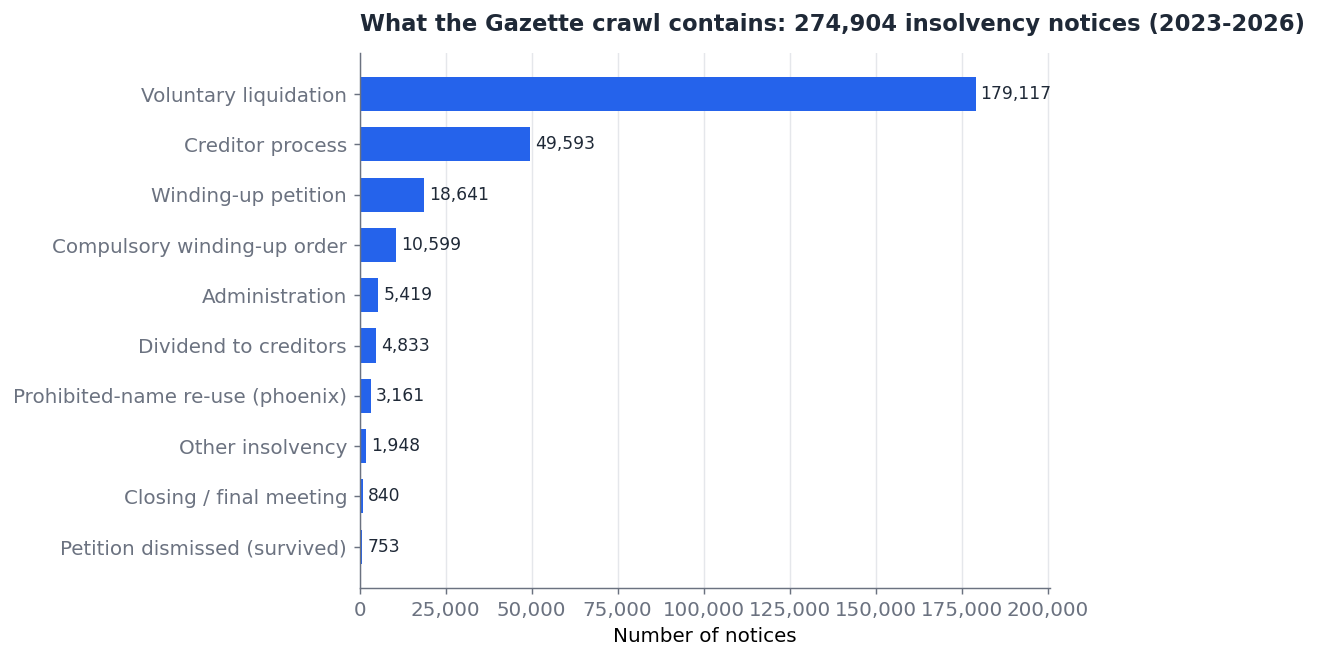

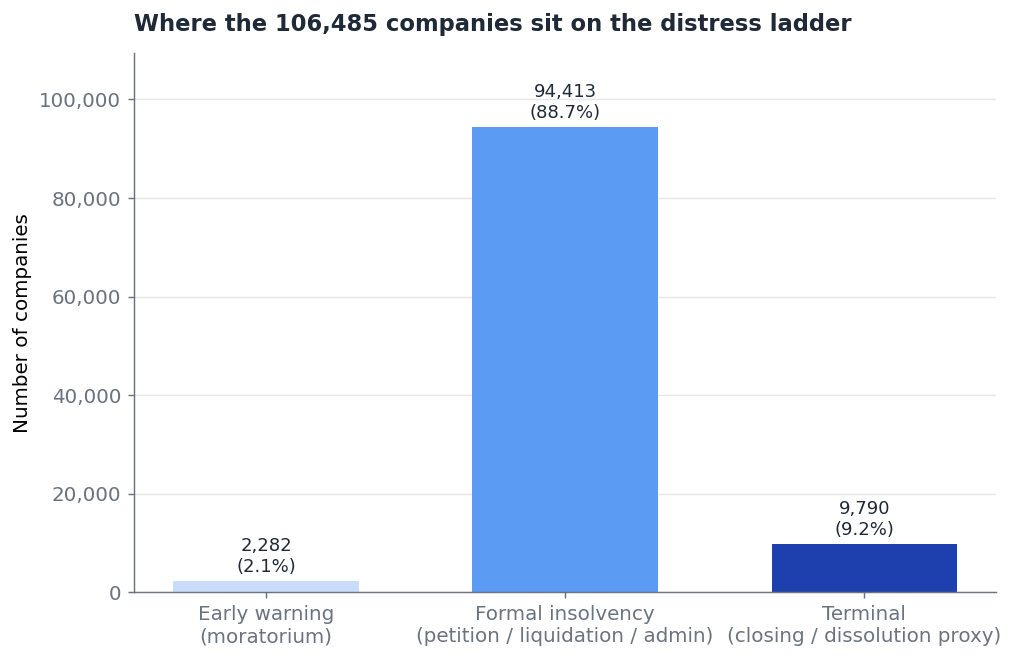

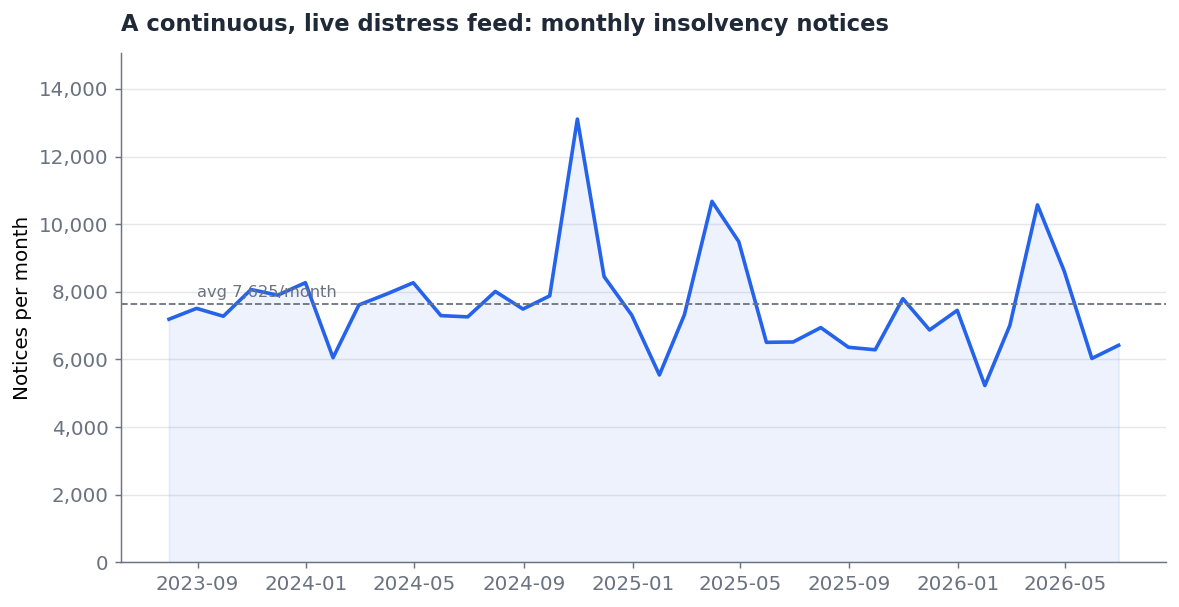

saved 3 charts -> C:\Users\visha\Lloyds_Github\lloyds-commercial-banking-intelligence-2026\notebooks


In [30]:
# ---- Step 6: three descriptive charts of the Gazette crawl ----
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from pathlib import Path

# robust path resolution: data lives in the OUTER data/processed tree
_here = Path.cwd()
_cands = [_here/".."/".."/"data"/"processed", _here/".."/"data"/"processed", Path("../../data/processed")]
DATA = next((c.resolve() for c in _cands if (c/"nb10_gazette_notices.csv").exists()), _cands[0].resolve())
OUT = _here if (_here.name == "notebooks") else _here/"notebooks"

INK, MUTED, GRID, BLUE = "#1f2937", "#6b7280", "#e5e7eb", "#2563eb"
plt.rcParams.update({"font.size":11,"axes.edgecolor":MUTED,"text.color":INK,
    "xtick.color":MUTED,"ytick.color":MUTED,"axes.spines.top":False,
    "axes.spines.right":False,"figure.dpi":130})
_k = FuncFormatter(lambda x,_: f"{int(x):,}")

n = pd.read_csv(DATA/"nb10_gazette_notices.csv", parse_dates=["notice_date"])
f = pd.read_csv(DATA/"nb10_gazette_company_features.csv")

FAM = {"Appointment of Liquidators":"Voluntary liquidation","Resolutions for Winding-up":"Voluntary liquidation",
 "Resolutions for Winding Up":"Voluntary liquidation","Winding-Up Orders":"Compulsory winding-up order",
 "Petitions to Wind Up (Companies)":"Winding-up petition","Service of Petition":"Winding-up petition",
 "Notices to Creditors":"Creditor process","Meetings of Creditors":"Creditor process",
 "Qualifying Decision Procedure":"Creditor process","Deemed Consent":"Creditor process","Notices to Members":"Creditor process",
 "Appointment of Administrators":"Administration","Administration Orders":"Administration",
 "Appointment of Administrative Receivers":"Administration","Notice of Intended Dividends":"Dividend to creditors",
 "Notice of Dividends":"Dividend to creditors",
 "Moratoria, Prohibited Names and Other: Re-use of a Prohibited Name":"Prohibited-name re-use (phoenix)",
 "Final Meetings":"Closing / final meeting","Annual Liquidation Meetings":"Closing / final meeting",
 "Dismissal of Winding Up Petition":"Petition dismissed (survived)"}
NOISE = {"Order of the British Empire","British Empire Medal","Overseas Territories and Dependencies",
 "Proclamations","Crown Office","Royal Victorian Order"}
n["family"] = n["notice_type"].map(FAM).fillna(
    n["notice_type"].apply(lambda t: "Other insolvency" if t not in NOISE else "noise"))
ins = n[n["family"]!="noise"]

# Fig 1: notice family composition
fam = ins["family"].value_counts().sort_values()
fig,ax = plt.subplots(figsize=(8.6,5.2))
ax.barh(fam.index, fam.values, color=BLUE, height=0.68)
for y,v in enumerate(fam.values): ax.text(v+fam.max()*0.008,y,f"{v:,}",va="center",fontsize=9.5,color=INK)
ax.xaxis.set_major_formatter(_k); ax.set_xlim(0,fam.max()*1.12)
ax.grid(axis="x",color=GRID,lw=0.8); ax.set_axisbelow(True)
ax.set_title(f"What the Gazette crawl contains: {len(ins):,} insolvency notices (2023-2026)",
    fontsize=12.5,fontweight="bold",pad=12,loc="left"); ax.set_xlabel("Number of notices")
fig.tight_layout(); fig.savefig(OUT/"nb10_gaz_fig1_notice_families.png",bbox_inches="tight"); plt.show()

# Fig 2: distress ladder (ordinal severity)
order=["early_warning","formal_insolvency","terminal"]
labels=["Early warning\n(moratorium)","Formal insolvency\n(petition / liquidation / admin)","Terminal\n(closing / dissolution proxy)"]
sev=f["gaz_severity_tier"].value_counts(); vals=[int(sev.get(k,0)) for k in order]; tot=sum(vals)
fig,ax=plt.subplots(figsize=(8.0,5.2))
ax.bar(labels,vals,color=["#c9ddfb","#5b9bf3","#1e40af"],width=0.62)
for i,v in enumerate(vals): ax.text(i,v+tot*0.01,f"{v:,}\n({v/tot*100:.1f}%)",ha="center",va="bottom",fontsize=10,color=INK)
ax.yaxis.set_major_formatter(_k); ax.set_ylim(0,max(vals)*1.16)
ax.grid(axis="y",color=GRID,lw=0.8); ax.set_axisbelow(True)
ax.set_title(f"Where the {tot:,} companies sit on the distress ladder",fontsize=12.5,fontweight="bold",pad=12,loc="left")
ax.set_ylabel("Number of companies")
fig.tight_layout(); fig.savefig(OUT/"nb10_gaz_fig2_distress_ladder.png",bbox_inches="tight"); plt.show()

# Fig 3: monthly notice volume over time
m=ins.set_index("notice_date").resample("ME").size(); m=m[m.index>="2023-07-01"]
fig,ax=plt.subplots(figsize=(9.2,4.8))
ax.plot(m.index,m.values,color=BLUE,lw=2.0); ax.fill_between(m.index,m.values,color=BLUE,alpha=0.08)
ax.axhline(m.mean(),color=MUTED,lw=1.0,ls="--")
ax.text(m.index[1],m.mean()*1.03,f"avg {m.mean():,.0f}/month",color=MUTED,fontsize=9)
ax.yaxis.set_major_formatter(_k); ax.set_ylim(0,m.max()*1.15)
ax.grid(axis="y",color=GRID,lw=0.8); ax.set_axisbelow(True)
ax.set_title("A continuous, live distress feed: monthly insolvency notices",fontsize=12.5,fontweight="bold",pad=12,loc="left")
ax.set_ylabel("Notices per month")
fig.tight_layout(); fig.savefig(OUT/"nb10_gaz_fig3_monthly_volume.png",bbox_inches="tight"); plt.show()
print("saved 3 charts ->", OUT)

### Step 7: matching and data-quality variables (trust the join)

The feature table is built **only from notices that carry a CompanyNumber** (the sole reliable
join key; name collisions are real). That is honest but it has a cost worth recording as
first-class columns, not hiding:

- **57%** of insolvency notices carry a CompanyNumber and are kept; **43%** are name-only and are
  **excluded** rather than guessed (they map to up to ~85k distinct names we cannot safely key).
- Every company in this table is therefore a `number` match. We still record the provenance columns
  (`gaz_has_company_number`, `gaz_match_method`, `gaz_name_only_match_flag`, `gaz_source_notice_urls`)
  so that if a future name-and-postcode matching pass is added, its lower-confidence rows sit beside
  these and can be filtered on `gaz_match_method`.

In [31]:
# ---- Step 7: matching / data-quality variables + honesty accounting ----
import pandas as pd
from pathlib import Path
_here = Path.cwd()
_cands = [_here/".."/".."/"data"/"processed", _here/".."/"data"/"processed", Path("../../data/processed")]
DATA = next((c.resolve() for c in _cands if (c/"nb10_gazette_notices.csv").exists()), _cands[0].resolve())

notices = pd.read_csv(DATA/"nb10_gazette_notices.csv", dtype=str)
notices["CompanyNumber"] = notices["CompanyNumber"].str.strip()
NOISE = {"Order of the British Empire","British Empire Medal","Overseas Territories and Dependencies",
         "Proclamations","Crown Office","Royal Victorian Order"}
ins = notices[~notices["notice_type"].isin(NOISE)].copy()
has_num = ins["CompanyNumber"].notna() & ~ins["CompanyNumber"].isin(["","nan"])
print("insolvency notices        :", f"{len(ins):,}")
print("  with CompanyNumber kept :", f"{int(has_num.sum()):,} ({has_num.mean()*100:.1f}%)")
print("  name-only excluded      :", f"{int((~has_num).sum()):,} ({(~has_num).mean()*100:.1f}%)")
print("  distinct excluded names :", f"{ins.loc[~has_num,'company_name'].str.upper().str.strip().nunique():,} (upper bound of unkeyed companies)")

keyed = ins[has_num]
urls = (keyed.dropna(subset=["notice_url"]).groupby("CompanyNumber")["notice_url"]
        .apply(lambda s: " | ".join(s.astype(str).head(5))))
feat = pd.read_csv(DATA/"nb10_gazette_company_features.csv", dtype={"CompanyNumber":str})
feat["CompanyNumber"] = feat["CompanyNumber"].str.strip()
feat["gaz_has_company_number"] = 1
feat["gaz_match_method"] = "number"
feat["gaz_name_only_match_flag"] = 0
feat["gaz_source_notice_urls"] = feat["CompanyNumber"].map(urls).fillna(feat.get("gaz_latest_notice_url"))
feat.to_csv(DATA/"nb10_gazette_company_features.csv", index=False)
print("\nfeature table ->", feat.shape, "| re-saved with 4 matching/quality columns")

insolvency notices        : 274,904
  with CompanyNumber kept : 156,768 (57.0%)
  name-only excluded      : 118,136 (43.0%)
  distinct excluded names : 84,815 (upper bound of unkeyed companies)

feature table -> (106664, 56) | re-saved with 4 matching/quality columns


### Step 8: combine onto the Companies House master and read out the at-risk watchlist

This is the "combine" step of the pipeline: left-join the Gazette features onto the structured
master (`filtered_bb_sme_sectors.csv`, ~1.37M **Active** companies) on `CompanyNumber`, filling
non-matches with `gaz_has_any_notice = 0` (absence is a valid signal, not a null).

**Key finding.** Only **1,033 of the 1.37M active companies (0.075%)** carry a Gazette distress
signal. That is expected, not a bug: a company deep in liquidation is usually no longer `Active`, so
the Gazette overlaps the active book only at its leading edge. Those 1,033 are precisely the
actionable set: **still Active, but with a live insolvency notice.** Their severity skews *earlier*
than the full distressed population (many early-warning / petition stages), and **773 have a notice
in the last 90 days**, which is what makes them a usable "Defend / at-risk" watchlist.

We save the 1,033-row watchlist (`nb10_active_gazette_watchlist.csv`) rather than a 1.37M-row copy of
the master: the full left-join is just this set plus zeros everywhere else.

> **Open decision for the team:** the master is Active-only. If we want the Gazette to cover more than
> the leading edge (e.g. recently dissolved firms, or prospects rather than existing exposure), the
> master itself would need widening beyond `Active`. That changes the shared structured dataset, so it
> is a Sam/Sneha + Viktor decision, not one to make here.

active companies with a Gazette distress signal: 1,033 / 1,372,321 (0.075%)
  recent (<=90d): 773 | open case: 782 | court-involved: 398

by severity tier:
 gaz_severity_tier
formal_insolvency    559
early_warning        304
terminal             149
none                  21

by sector:
 sector
Technology, legal & professional    518
Manufacturing                       278
Fast growth & emerging              237

saved watchlist -> nb10_active_gazette_watchlist.csv (1033 rows)


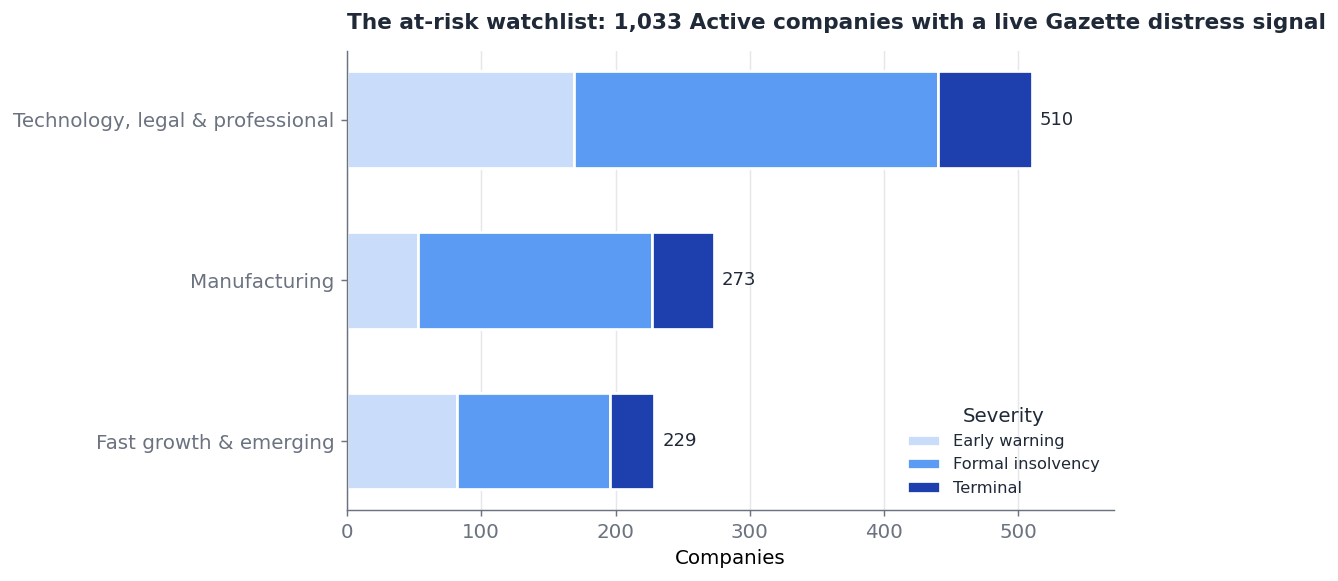

In [32]:
# ---- Step 8: combine onto master, build the at-risk watchlist, chart it ----
import matplotlib.pyplot as plt
INK, MUTED, GRID = "#1f2937", "#6b7280", "#e5e7eb"
plt.rcParams.update({"font.size":11,"axes.edgecolor":MUTED,"text.color":INK,"xtick.color":MUTED,
    "ytick.color":MUTED,"axes.spines.top":False,"axes.spines.right":False,"figure.dpi":130})
OUT = _here if _here.name == "notebooks" else _here/"notebooks"

master = pd.read_csv(DATA/"filtered_bb_sme_sectors.csv", dtype=str,
    usecols=lambda c: c.strip() in ("CompanyNumber","CompanyName","sector","segment"))
master.columns = [c.strip() for c in master.columns]
master["CompanyNumber"] = master["CompanyNumber"].str.strip()

merged = master.merge(feat.drop(columns=["company_name"]), on="CompanyNumber", how="left")
merged["gaz_has_any_notice"] = merged["gaz_has_any_notice"].fillna(0).astype(int)
n = int(merged["gaz_has_any_notice"].sum())
print(f"active companies with a Gazette distress signal: {n:,} / {len(master):,} ({n/len(master)*100:.3f}%)")

watch = merged[merged["gaz_has_any_notice"] == 1].copy()
num = lambda col: int(pd.to_numeric(watch[col], errors="coerce").fillna(0).sum())
print("  recent (<=90d):", num("gaz_recent_notice_90d_flag"),
      "| open case:", num("gaz_active_case_flag"),
      "| court-involved:", num("gaz_court_involved_flag"))
print("\nby severity tier:\n", watch["gaz_severity_tier"].value_counts().to_string())
print("\nby sector:\n", watch["sector"].value_counts().to_string())
watch.to_csv(DATA/"nb10_active_gazette_watchlist.csv", index=False)
print(f"\nsaved watchlist -> nb10_active_gazette_watchlist.csv ({len(watch)} rows)")

# chart: watchlist by sector, stacked by severity tier
tiers = ["early_warning","formal_insolvency","terminal"]
tlab = {"early_warning":"Early warning","formal_insolvency":"Formal insolvency","terminal":"Terminal"}
cols = {"early_warning":"#c9ddfb","formal_insolvency":"#5b9bf3","terminal":"#1e40af"}
piv = (watch[watch["gaz_severity_tier"].isin(tiers)]
       .pivot_table(index="sector", columns="gaz_severity_tier", aggfunc="size", fill_value=0)
       .reindex(columns=tiers, fill_value=0))
piv["tot"] = piv.sum(axis=1); piv = piv.sort_values("tot")
fig, ax = plt.subplots(figsize=(8.8,4.6)); left = [0]*len(piv)
for t in tiers:
    ax.barh(piv.index, piv[t], left=left, color=cols[t], label=tlab[t], height=0.6, edgecolor="white", linewidth=1.5)
    left = [l+v for l,v in zip(left, piv[t])]
for y,tot in enumerate(piv["tot"]): ax.text(tot+6, y, f"{int(tot)}", va="center", fontsize=10, color=INK)
ax.set_xlim(0, piv["tot"].max()*1.12); ax.grid(axis="x", color=GRID, lw=0.8); ax.set_axisbelow(True)
ax.set_title(f"The at-risk watchlist: {len(watch):,} Active companies with a live Gazette distress signal",
    fontsize=12, fontweight="bold", pad=12, loc="left")
ax.set_xlabel("Companies"); ax.legend(title="Severity", loc="lower right", frameon=False, fontsize=9)
fig.tight_layout(); fig.savefig(OUT/"nb10_gaz_fig4_watchlist.png", bbox_inches="tight"); plt.show()